# Supplementary code for paper "Interpretable Recognition of Cognitive Distortions in Natural Language Texts"
## Second, combined, half-synthetic dataset

In [1]:
import os, sys
import datetime as dt
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import random
import datetime as dt
import plotly.graph_objects as go

#force reimport
if 'api' in sys.modules:
    del sys.modules['api']
if 'plot' in sys.modules:
    del sys.modules['plot']
if 'util' in sys.modules:
    del sys.modules['util']
if 'recognition_evaluators' in sys.modules:
    del sys.modules['recognition_evaluators']

from api import TextMetrics, load_ngrams, punct, tokenize_re, build_ngrams, Learner
from plot import plot_dict, plot_dict_bars, matrix_plot, plot_bar_from_list, \
    build_triple_list, build_triple_matrix, plot_bar_from_list_minmax
from util import dictcount, contains_seq, agg_min_max_avg_mpe
from recognition_evaluators import df2labeled, language_metrics, our_evaluator_test, our_evaluator_tm, our_evaluator_top, \
    our_evaluator_true, our_evaluator_false, our_evaluator_random, pre_rec_f1_from_counts, evaluate_tm_df, evaluate_metrics, evaluate_model, \
    full_test_circle, dictval, our_evaluator_top1

grand_t0 = dt.datetime.now()

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\kzvau\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


In [2]:
# Paper section: "Models with Data Provided" 
# authors provided combined dataset consisting ... for multiple distortions (Babacan 2024) using the RoBERTa 
# model (Babacan, O˘guz, and Beyito˘glu 2025) reporting F 1=0.77 on multi-class recognition task

from datasets import load_dataset

DS = 'Babakan24'

# dataset: https://huggingface.co/datasets/halilbabacan/combined_synthetic_cognitive_distortions/tree/main
ds = load_dataset(
    "halilbabacan/combined_synthetic_cognitive_distortions",
    split="train",
)

df = ds.to_pandas()
df = df.rename(columns={'text': 'Patient Question', 'label': 'Dominant Distortion'})
df.insert(1, 'Distorted part', value = np.nan)
df.insert(3, 'Secondary Distortion (Optional)', value = np.nan)
# Remove the row with index 738 because it contains a NaN in the text column
df = df.drop(index=738)


mapping = {
    "Labelling":            "Labeling",
    "Mental Filter":        "Mental filter",
    "Should Statements":    "Should statements",
    "All-or-Nothing Thinking": "All-or-nothing thinking"
}

df['Dominant Distortion'] = df['Dominant Distortion'].map(mapping).fillna(df['Dominant Distortion'])

df


,Patient Question,Distorted part,Dominant Distortion,Secondary Distortion (Optional)
0,John walked past me without saying a word He m...,NaN,Mind Reading,NaN
1,"During the meeting, Sarah didn't look at me on...",NaN,Mind Reading,NaN
2,Mike didn't respond to my text right away He m...,NaN,Mind Reading,NaN
3,Jessica didn't smile when she saw me She must ...,NaN,Mind Reading,NaN
4,Tom didn't invite me to his party He must not ...,NaN,Mind Reading,NaN
...,...,...,...,...
4526,I’m a 21 year old female. I spent most of my l...,NaN,No Distortion,NaN
4527,Now I am at university my peers around me all ...,NaN,Overgeneralization,NaN
4528,He claims he’s severely depressed and has outb...,NaN,Mental filter,NaN
4529,From the U.S.: I am a 21 year old woman who ha...,NaN,No Distortion,NaN


In [3]:
#Paper Section: "Experimental Setup"

model_multiclass_path = '../../data/models/distortions/babacan2024'
model_name = 'multiclasss'
inclusion_thresholds = [0,10,20,30,40,50,60,70,80,90]
detection_thresholds = [10,20,30,40,50,60,70,80,90]
selection_metrics = ['F','UF','FN','UFN','TF-IDF','FCR','CFR','MR','NLMI']
n_max_values = [1,2,3,4,5]
splits = [0,1,2]

if not os.path.exists(model_multiclass_path):
    os.makedirs(model_multiclass_path)
print(model_multiclass_path)


../../data/models/distortions/babacan2024


# Grid search
## Perform a grid search over all hyper-parameters to determine the best combination for building the model
### Non-Weighted Model and Recognition

In [4]:
# Paper section: "Experimental Setup"

results1 = []
for shift in splits:
    accumulator = []
    for n_max in n_max_values:
        full_test_circle(df,model_multiclass_path,f'{model_name}-{shift+1}',
                validation_fraction=5,inclusion_thresholds=inclusion_thresholds,
                detection_thresholds=detection_thresholds,n_max=n_max, selection_metrics = selection_metrics,
                all_scores=False,averages=False,split_shift=shift,evaluator=our_evaluator_top1,accumulator=accumulator)
    results1.append(accumulator)


Shift=0: train=3623, test=907
Labels count: defaultdict(<class 'int'>, {'Mind_Reading': 349, 'Overgeneralization': 353, 'Magnification': 322, 'Labeling': 283, 'Personalization': 283, 'Fortune-telling': 268, 'Emotional_Reasoning': 272, 'Mental_filter': 257, 'Should_statements': 248, 'All-or-nothing_thinking': 236, 'No_Distortion': 752})
Shift=0: train=3623, test=907
Labels count: defaultdict(<class 'int'>, {'Mind_Reading': 349, 'Overgeneralization': 353, 'Magnification': 322, 'Labeling': 283, 'Personalization': 283, 'Fortune-telling': 268, 'Emotional_Reasoning': 272, 'Mental_filter': 257, 'Should_statements': 248, 'All-or-nothing_thinking': 236, 'No_Distortion': 752})
Shift=0: train=3623, test=907
Labels count: defaultdict(<class 'int'>, {'Mind_Reading': 349, 'Overgeneralization': 353, 'Magnification': 322, 'Labeling': 283, 'Personalization': 283, 'Fortune-telling': 268, 'Emotional_Reasoning': 272, 'Mental_filter': 257, 'Should_statements': 248, 'All-or-nothing_thinking': 236, 'No_Disto

In [5]:
# Search the best hyper-parameters based on three runs with min, max and average F1 and its MPE evaluated  

summary = []
for l1,l2,l3 in zip(results1[0],results1[1],results1[2]):
    summary.append( l1[0:4] + agg_min_max_avg_mpe((l1[4],l2[4],l3[4])))
summary = sorted(summary, key=lambda x: (-x[6],x[2],x[0],-x[1],x[3])) # sort by -F1avg, SM, NM, -IT, RT
NM, IT, SM, DT = summary[0][:4] 
print(NM, IT, SM, DT)
print()
print([s for s in summary if s[2]=='MR'][:1])
print([s for s in summary if s[2]=='FCR'][:1])
print([s for s in summary if s[2]=='FN'][:1])
print()
for s in summary[:20]:
    print(s)

4 80 MR 40

[(4, 80, 'MR', 40, 0.8871984818076772, 0.9164508106001581, 0.9027830220931646, 1.1508516741452492)]
[(2, 70, 'FCR', 60, 0.8667840370779727, 0.8849712398029913, 0.8743744669660739, 0.8079507684075214)]
[(2, 70, 'FN', 60, 0.8667840370779727, 0.8849712398029913, 0.8743744669660739, 0.8079507684075214)]

(4, 80, 'MR', 40, 0.8871984818076772, 0.9164508106001581, 0.9027830220931646, 1.1508516741452492)
(5, 80, 'MR', 40, 0.8871984818076772, 0.9164508106001581, 0.9027830220931646, 1.1508516741452492)
(4, 80, 'NLMI', 40, 0.8871984818076772, 0.9164508106001581, 0.9027830220931646, 1.1508516741452492)
(5, 80, 'NLMI', 40, 0.8871984818076772, 0.9164508106001581, 0.9027830220931646, 1.1508516741452492)
(4, 90, 'MR', 40, 0.8852032836559772, 0.9150539852033326, 0.9017342476588895, 1.2221608192458375)
(5, 90, 'MR', 40, 0.8852032836559772, 0.9150539852033326, 0.9017342476588895, 1.2221608192458375)
(4, 90, 'NLMI', 40, 0.8852032836559772, 0.9150539852033326, 0.9017342476588895, 1.222160819245

Shift=0: train=3623, test=907
Labels count: defaultdict(<class 'int'>, {'Mind_Reading': 349, 'Overgeneralization': 353, 'Magnification': 322, 'Labeling': 283, 'Personalization': 283, 'Fortune-telling': 268, 'Emotional_Reasoning': 272, 'Mental_filter': 257, 'Should_statements': 248, 'All-or-nothing_thinking': 236, 'No_Distortion': 752})


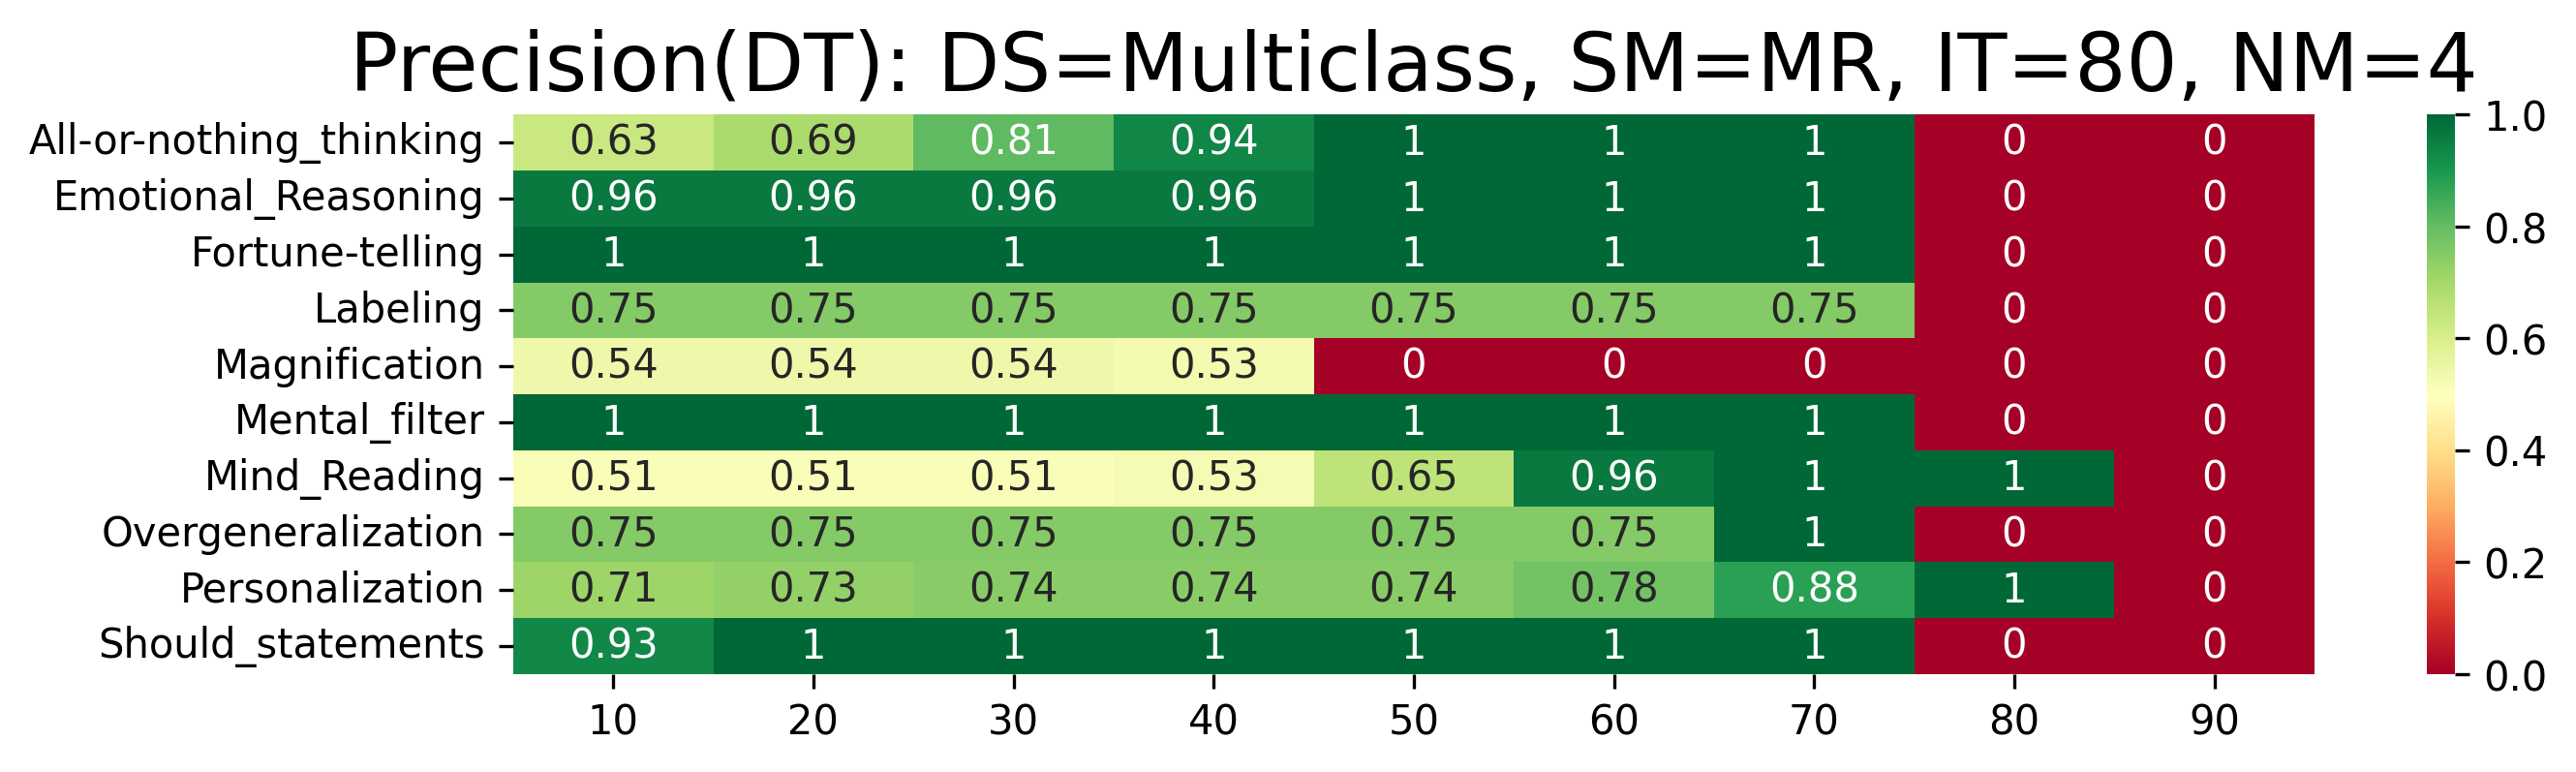

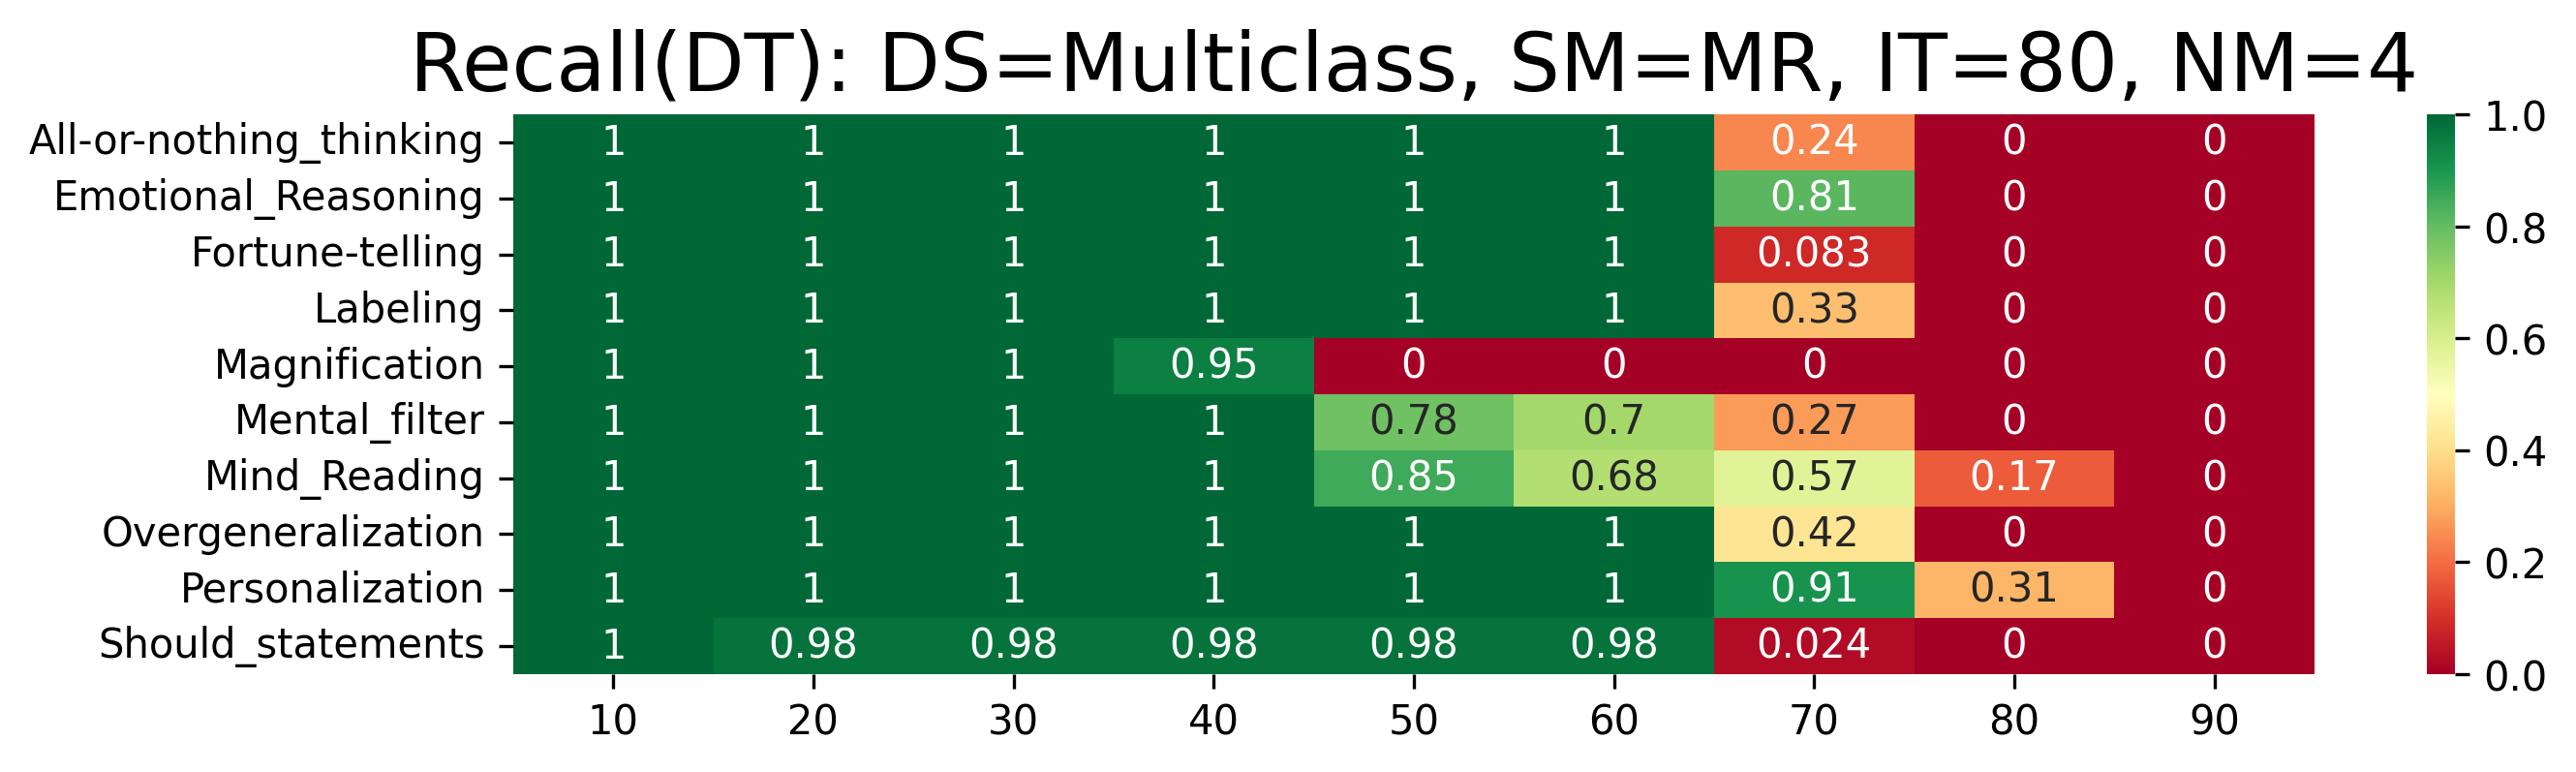

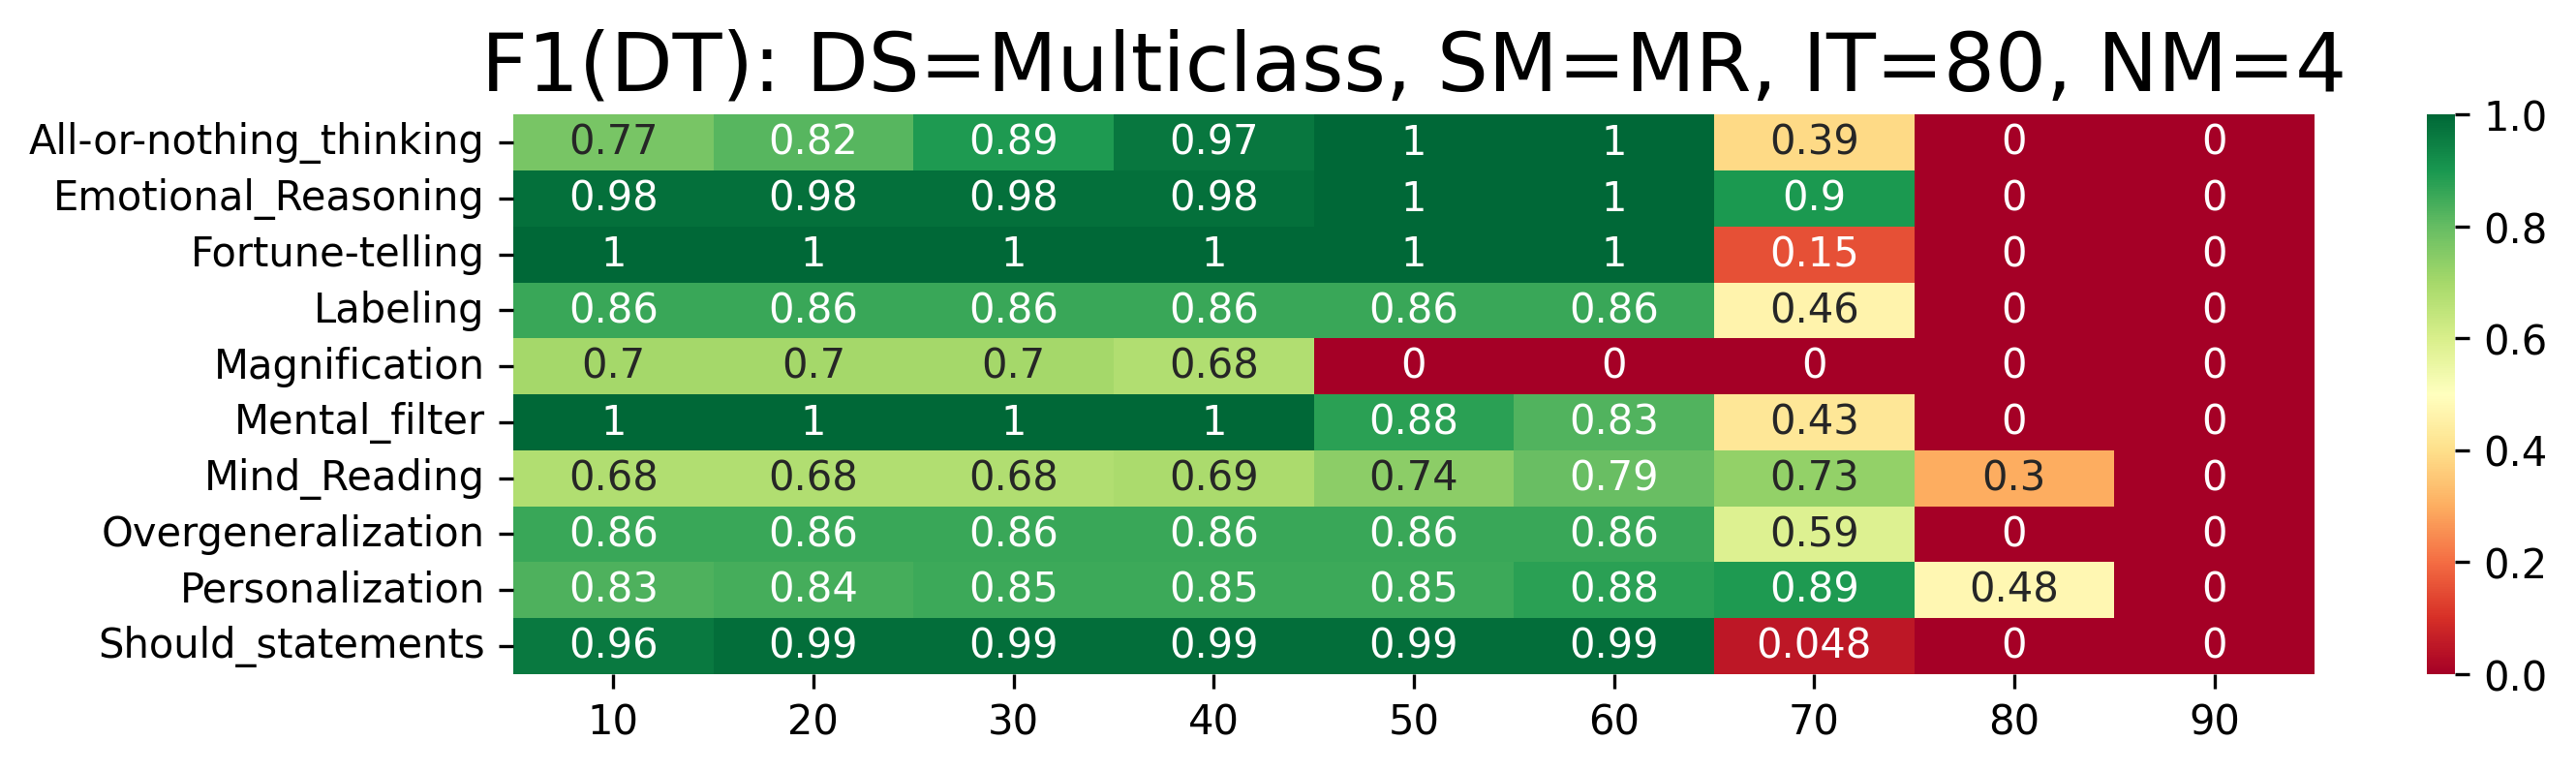

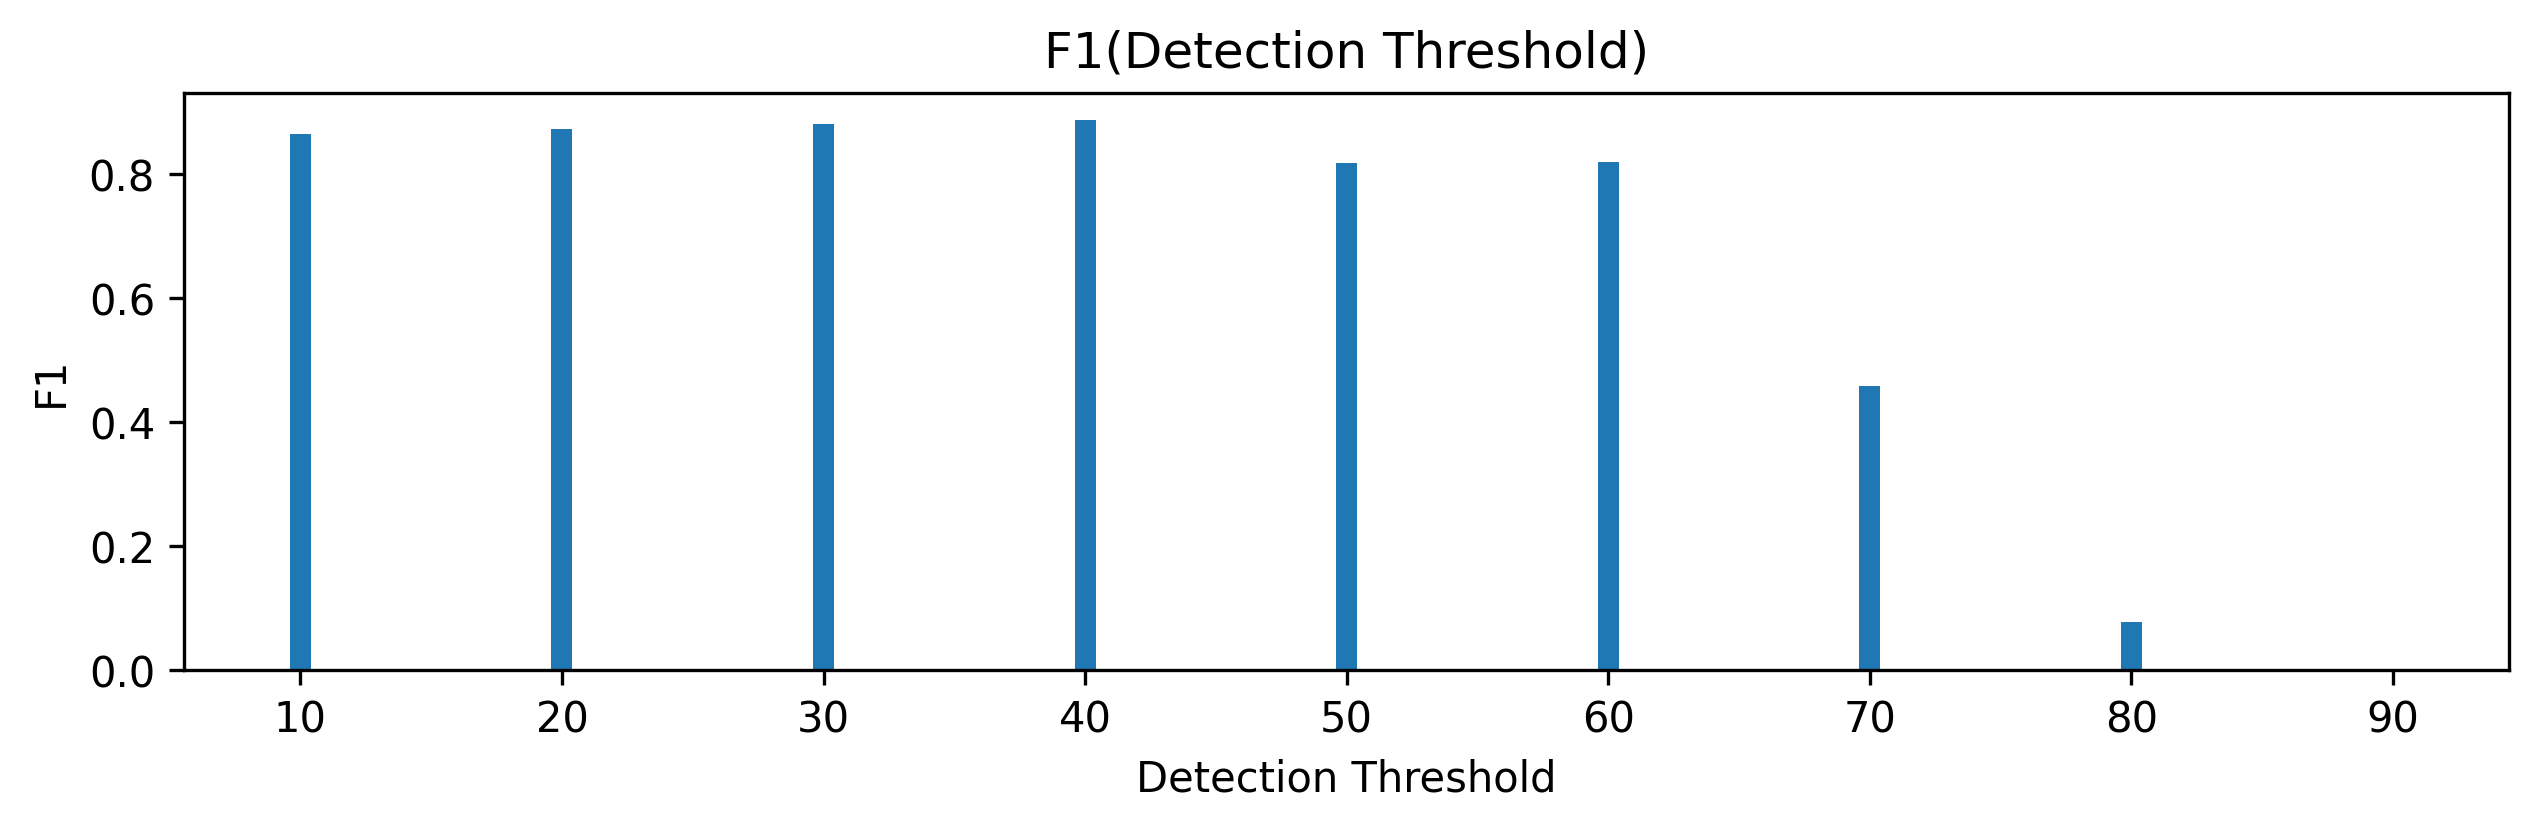

In [6]:
# Explore precison, recall and F1 for specific distortions with best NM, SM, and IT for range of DT 

shift = 0
full_test_circle(df,model_multiclass_path,f'{model_name}-{shift+1}',
                validation_fraction=5,inclusion_thresholds=[IT],
                detection_thresholds=detection_thresholds,n_max=NM, selection_metrics = [SM],
                all_scores=True,averages=True,split_shift=shift,evaluator=our_evaluator_top1)

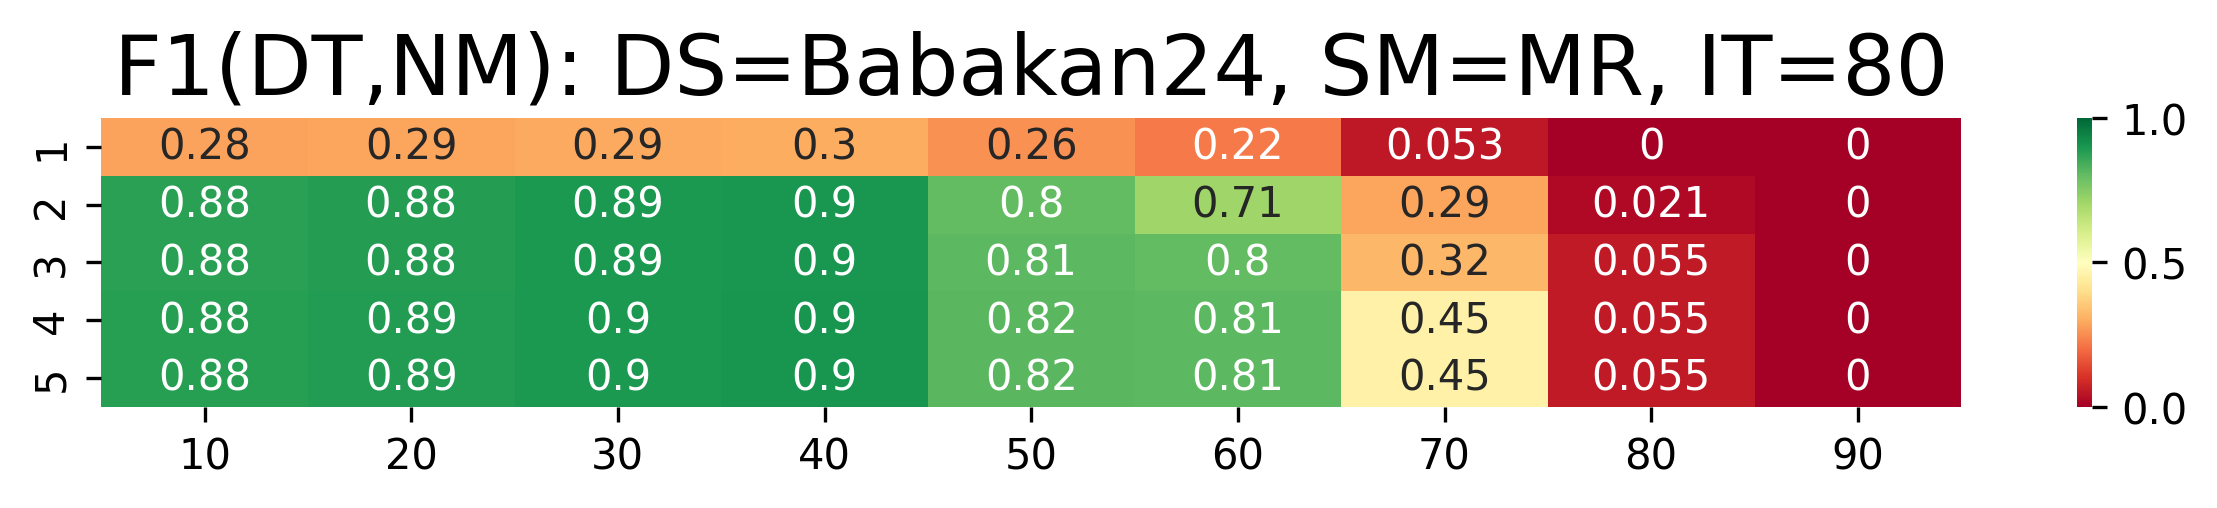

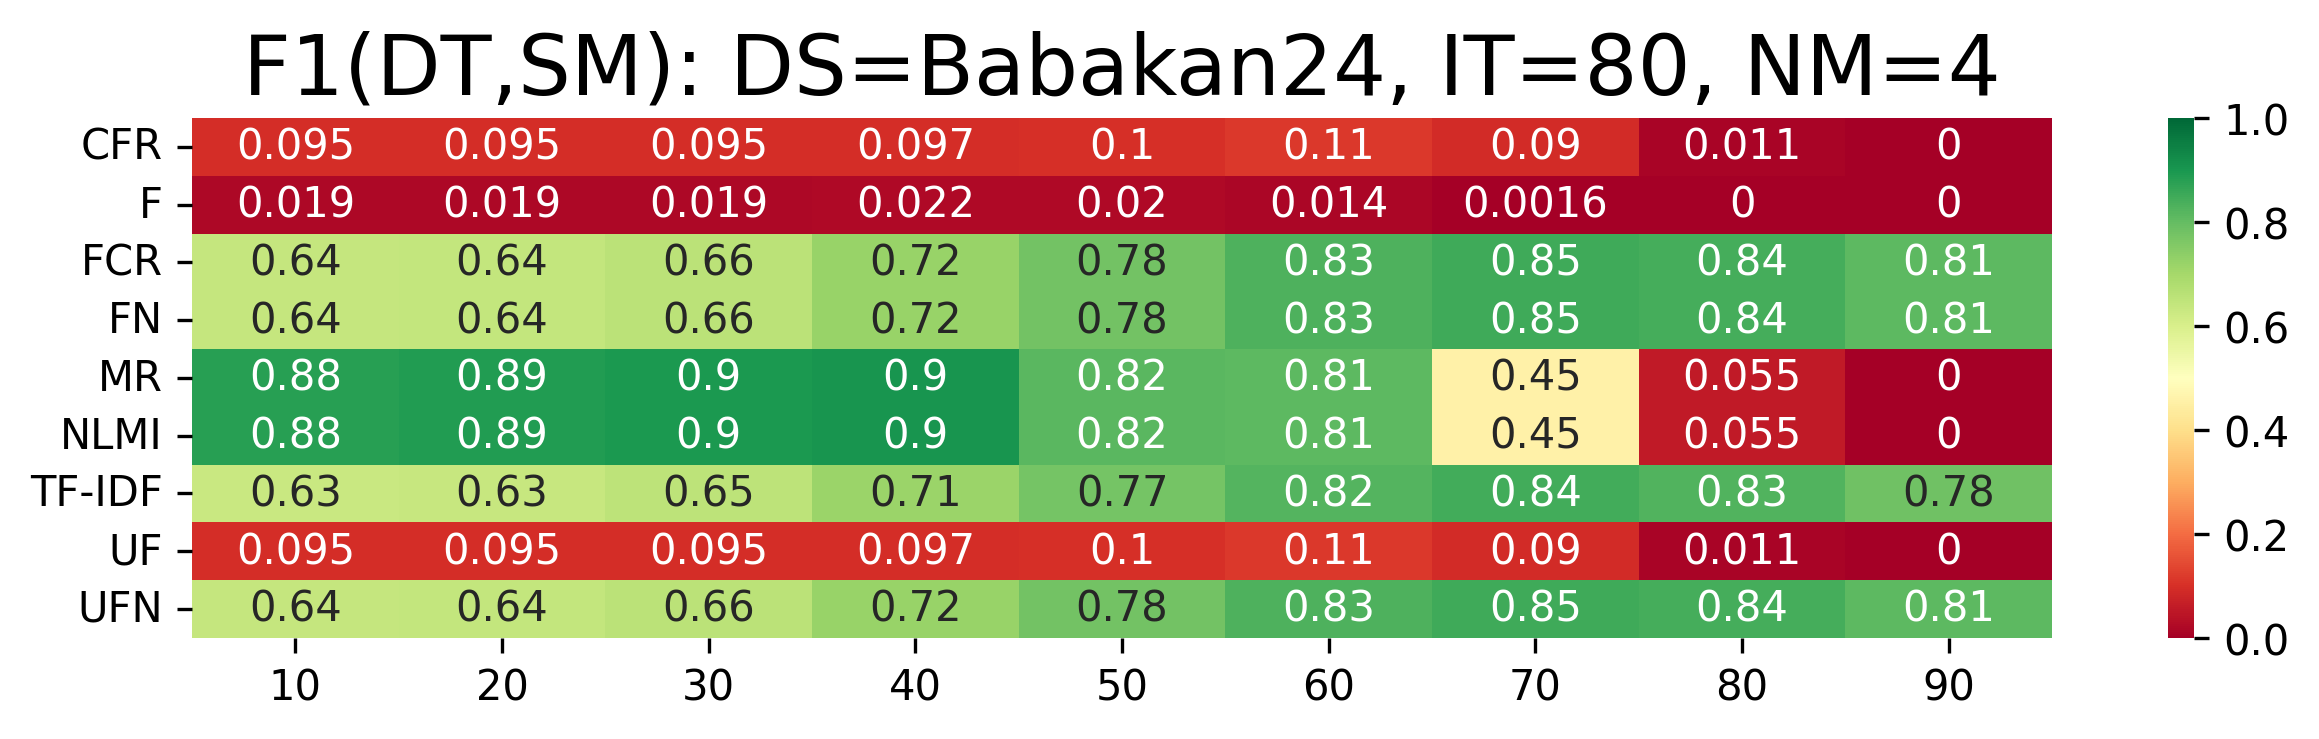

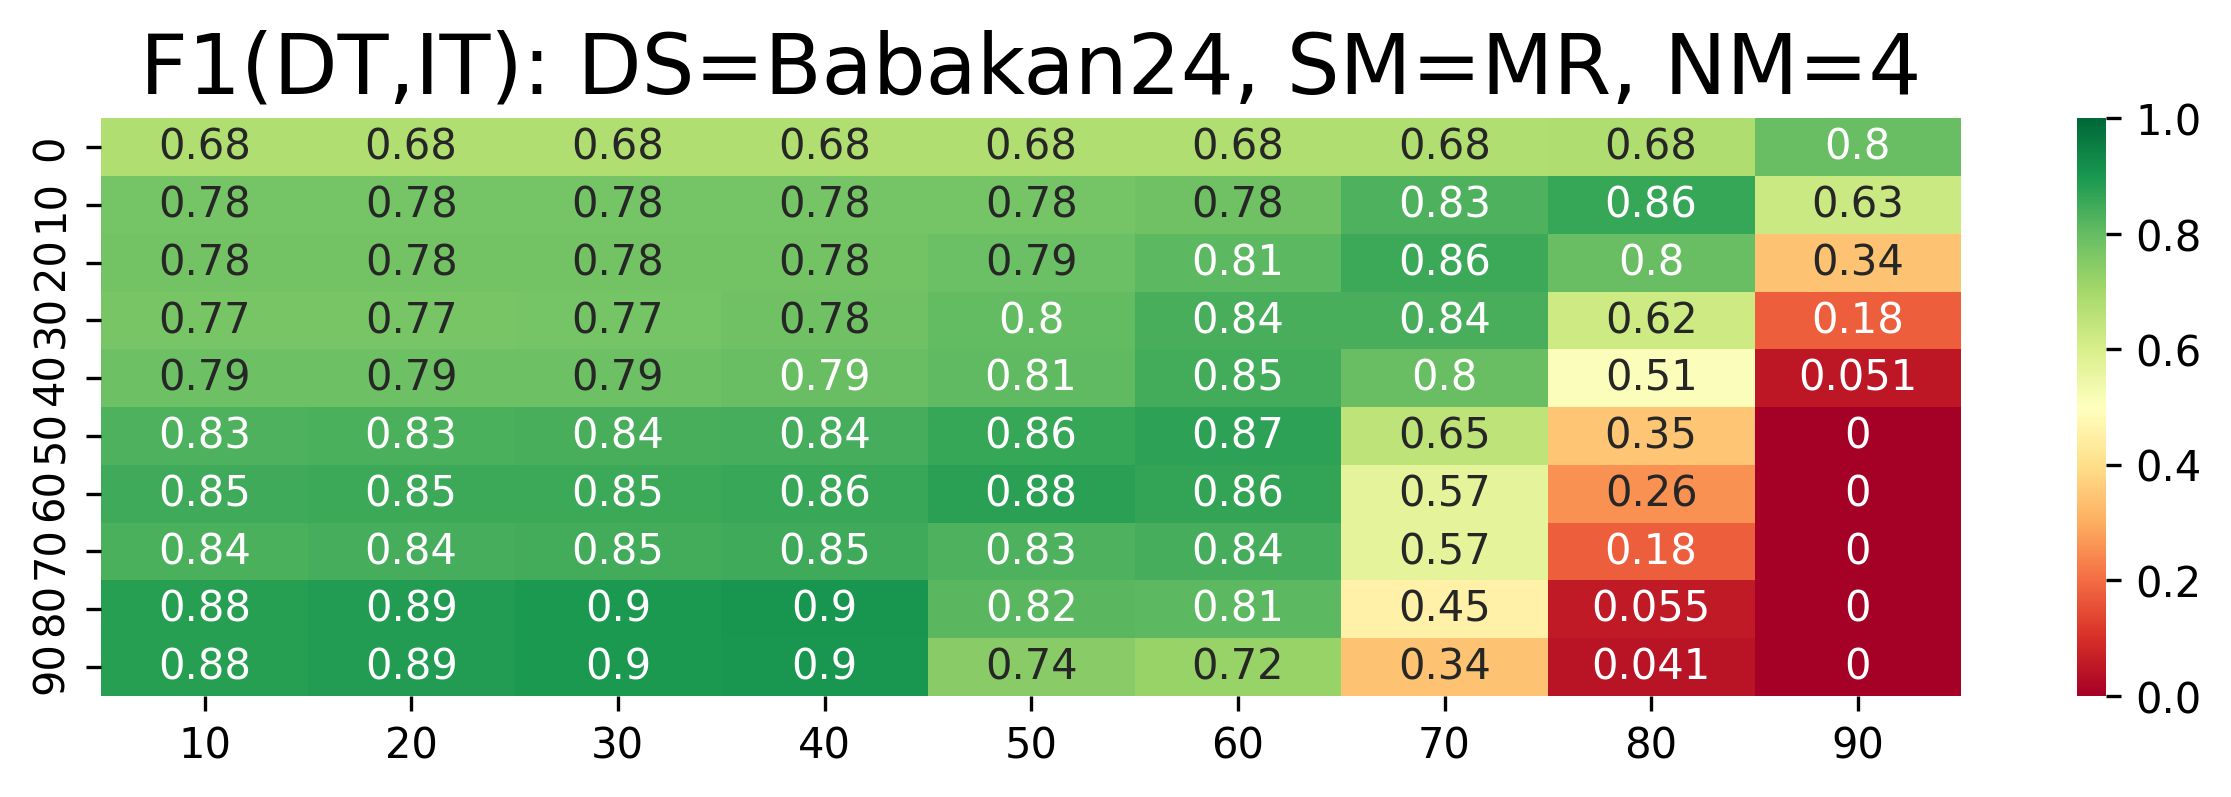

In [7]:
# Render average F1 scores for ranges of NM, SM, and IT and range of DT 

m = build_triple_matrix(summary,0,3,{2:SM,1:IT},6,n_max_values,detection_thresholds)
matrix_plot(n_max_values, detection_thresholds, m, 1.0, title = f'F1(DT,NM): DS={DS}, SM={SM}, IT={IT}', vmin = 0, vmax = 1.0, titlefontsize = 20, dpi = 300, width = 10)

m = build_triple_matrix(summary,2,3,{0:NM,1:IT},6,selection_metrics,detection_thresholds)
matrix_plot(sorted(selection_metrics), detection_thresholds, m, 1.0, title = f'F1(DT,SM): DS={DS}, IT={IT}, NM={NM}', vmin = 0, vmax = 1.0, titlefontsize = 20, dpi = 300, width = 10)

m = build_triple_matrix(summary,1,3,{0:NM,2:SM},6,inclusion_thresholds, detection_thresholds)
matrix_plot(sorted(inclusion_thresholds), detection_thresholds, m, 1.0, title = f'F1(DT,IT): DS={DS}, SM={SM}, NM={NM}', vmin = 0, vmax = 1.0, titlefontsize = 20, dpi = 300, width = 10)


### Weighted Model and Recognition

In [8]:
# Paper section: "Experimental Setup" 

results1 = []
for shift in splits:
    accumulator = []
    for n_max in n_max_values:
        full_test_circle(df,model_multiclass_path,f'{model_name}-{shift+1}',
                validation_fraction=5,inclusion_thresholds=inclusion_thresholds,
                detection_thresholds=detection_thresholds,n_max=n_max, selection_metrics = selection_metrics,
                weighted=True,all_scores=False,averages=False,split_shift=shift,
                evaluator=our_evaluator_top1,accumulator=accumulator)
    results1.append(accumulator)

Shift=0: train=3623, test=907
Labels count: defaultdict(<class 'int'>, {'Mind_Reading': 349, 'Overgeneralization': 353, 'Magnification': 322, 'Labeling': 283, 'Personalization': 283, 'Fortune-telling': 268, 'Emotional_Reasoning': 272, 'Mental_filter': 257, 'Should_statements': 248, 'All-or-nothing_thinking': 236, 'No_Distortion': 752})
Shift=0: train=3623, test=907
Labels count: defaultdict(<class 'int'>, {'Mind_Reading': 349, 'Overgeneralization': 353, 'Magnification': 322, 'Labeling': 283, 'Personalization': 283, 'Fortune-telling': 268, 'Emotional_Reasoning': 272, 'Mental_filter': 257, 'Should_statements': 248, 'All-or-nothing_thinking': 236, 'No_Distortion': 752})
Shift=0: train=3623, test=907
Labels count: defaultdict(<class 'int'>, {'Mind_Reading': 349, 'Overgeneralization': 353, 'Magnification': 322, 'Labeling': 283, 'Personalization': 283, 'Fortune-telling': 268, 'Emotional_Reasoning': 272, 'Mental_filter': 257, 'Should_statements': 248, 'All-or-nothing_thinking': 236, 'No_Disto

In [9]:
# Search the best hyper-parameters based on three runs with min, max and average F1 and its MPE evaluated  

summary_weighted = []
for l1,l2,l3 in zip(results1[0],results1[1],results1[2]):
    summary_weighted.append( l1[0:4] + agg_min_max_avg_mpe((l1[4],l2[4],l3[4])))
summary_weighted = sorted(summary_weighted, key=lambda x: (-x[6],x[2],x[0],-x[1],x[3])) # sort by -F1avg, SM, NM, -IT, RT
NM, IT, SM, DT = summary_weighted[0][:4]
F1 = summary_weighted[0][6]
print(f'DS={DS}, NM={NM}, IT={IT}, SM={SM}, DT={DT}, F1={F1}')
print()
for s in summary_weighted[:20]:
    print(s)

DS=Babakan24, NM=2, IT=60, SM=FN, DT=60, F1=0.8758896838128489

(2, 60, 'FN', 60, 0.8661429048060828, 0.8943613091779679, 0.8758896838128489, 1.4059324065187344)
(2, 60, 'FCR', 60, 0.8660956046290483, 0.8943613091779679, 0.8755332728710329, 1.4336433112887683)
(2, 60, 'UFN', 60, 0.8660956046290483, 0.8943613091779679, 0.8755332728710329, 1.4336433112887683)
(2, 70, 'FCR', 60, 0.8617147426038352, 0.8908984322464392, 0.8752601399417946, 1.1911348097937584)
(2, 70, 'FN', 60, 0.8617147426038352, 0.8908984322464392, 0.8752601399417946, 1.1911348097937584)
(2, 70, 'UFN', 60, 0.8617147426038352, 0.8908984322464392, 0.8752601399417946, 1.1911348097937584)
(2, 50, 'FCR', 60, 0.8685162053211275, 0.8824256016553825, 0.8731916478912255, 0.7049963419796097)
(2, 50, 'UFN', 60, 0.8685162053211275, 0.8824256016553825, 0.8731916478912255, 0.7049963419796097)
(2, 50, 'FN', 60, 0.8674296862064393, 0.8782400193764939, 0.8712073370511707, 0.5381560375074571)
(2, 40, 'FCR', 60, 0.8650408535379901, 0.8774513

Shift=0: train=3623, test=907
Labels count: defaultdict(<class 'int'>, {'Mind_Reading': 349, 'Overgeneralization': 353, 'Magnification': 322, 'Labeling': 283, 'Personalization': 283, 'Fortune-telling': 268, 'Emotional_Reasoning': 272, 'Mental_filter': 257, 'Should_statements': 248, 'All-or-nothing_thinking': 236, 'No_Distortion': 752})


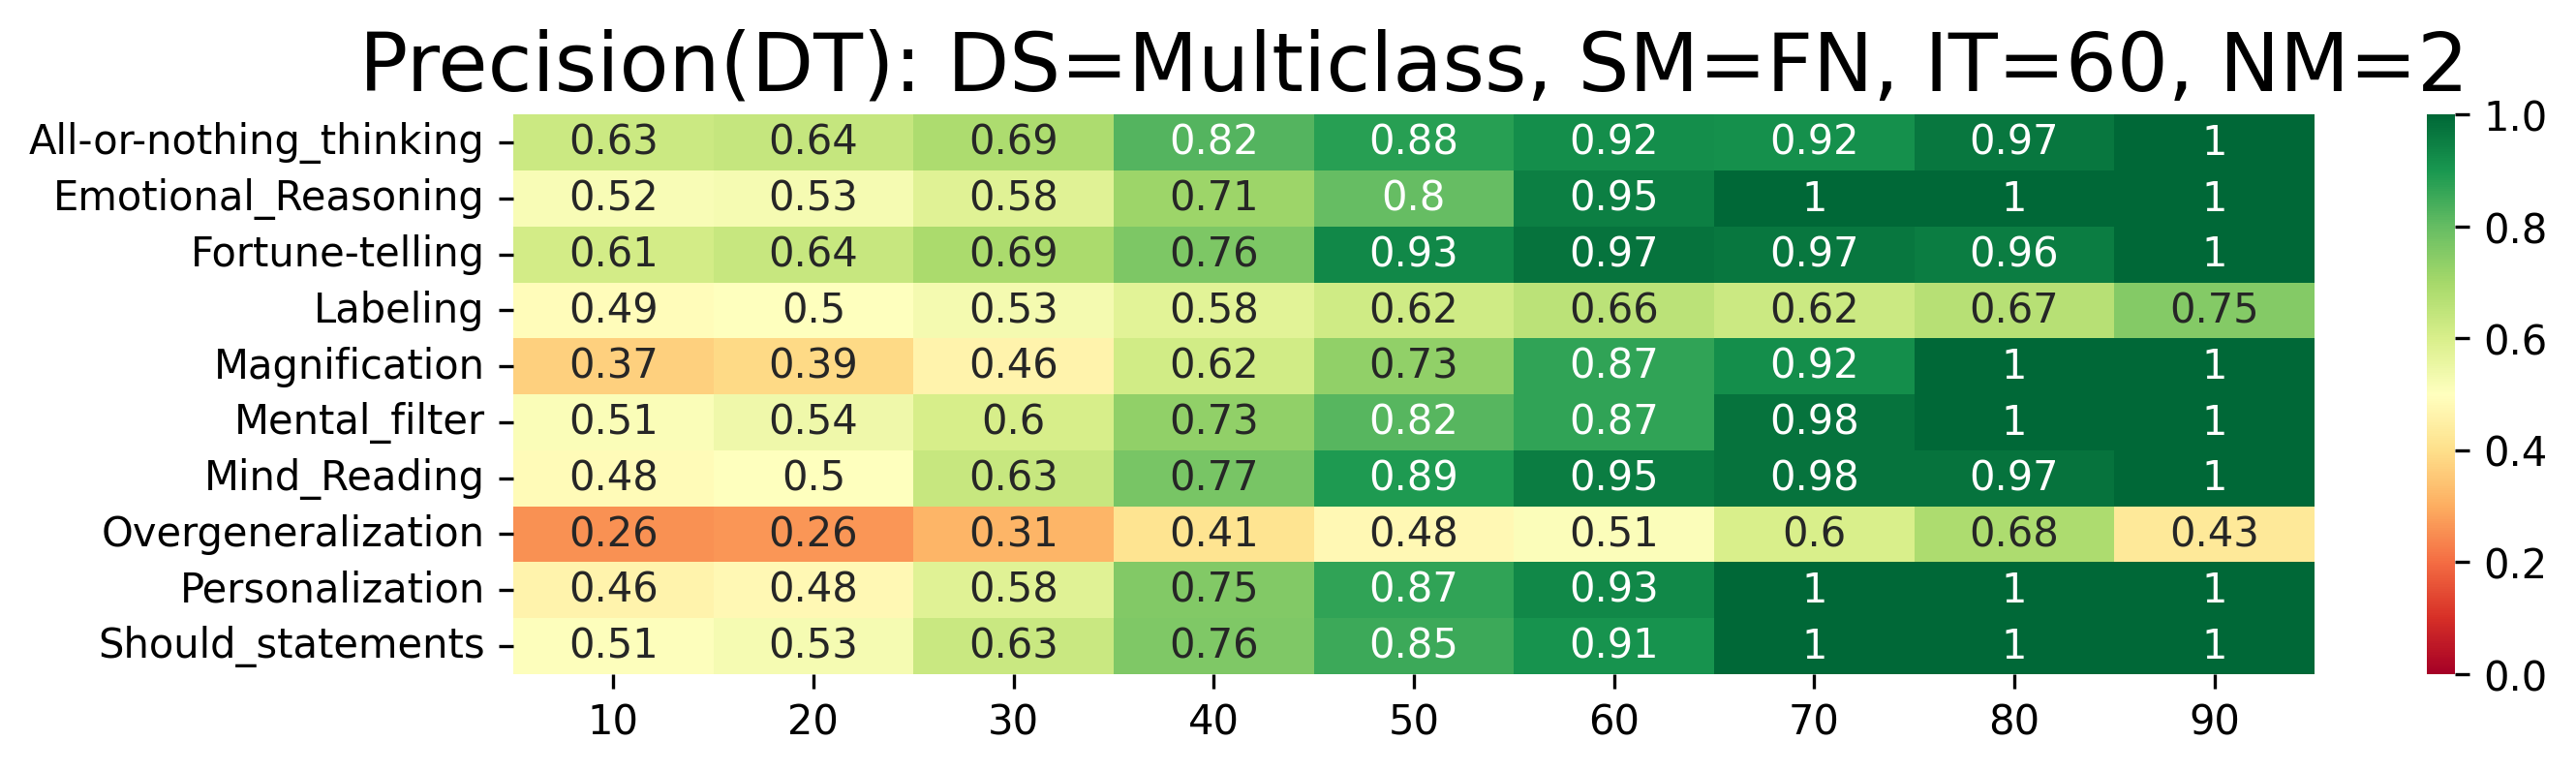

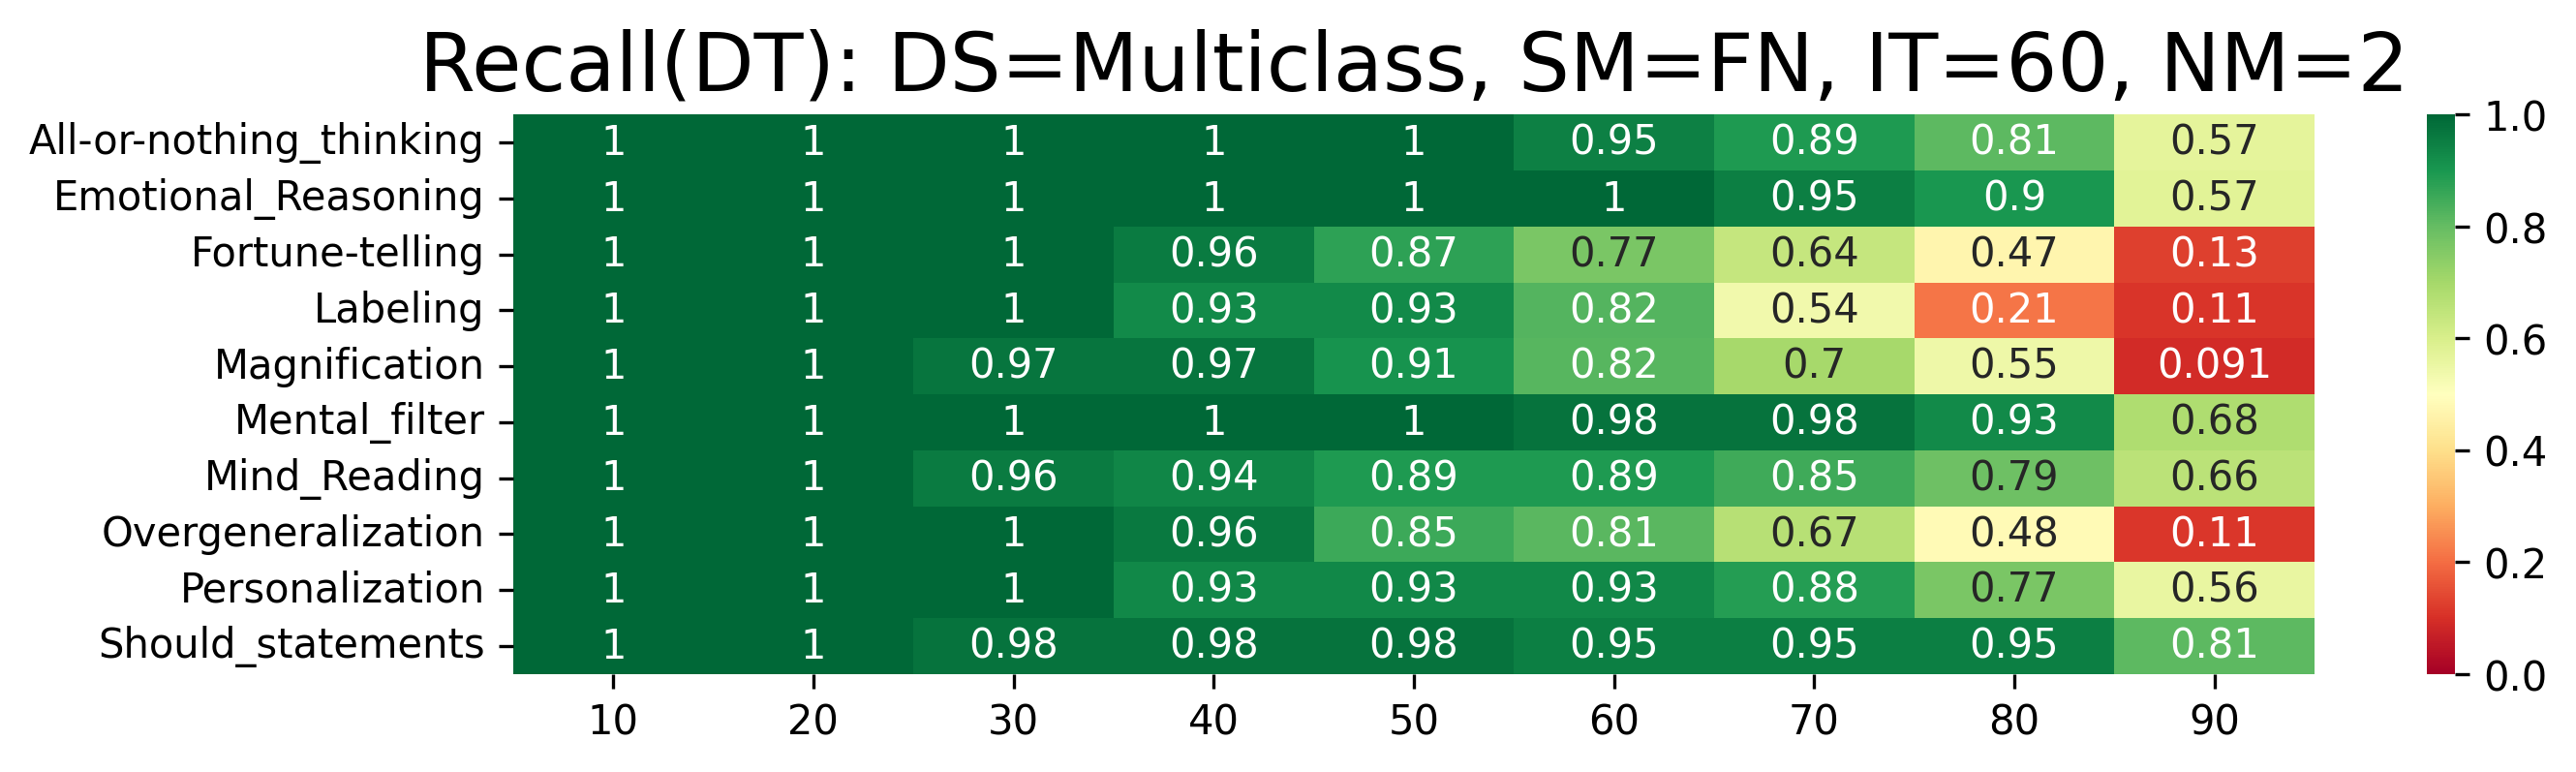

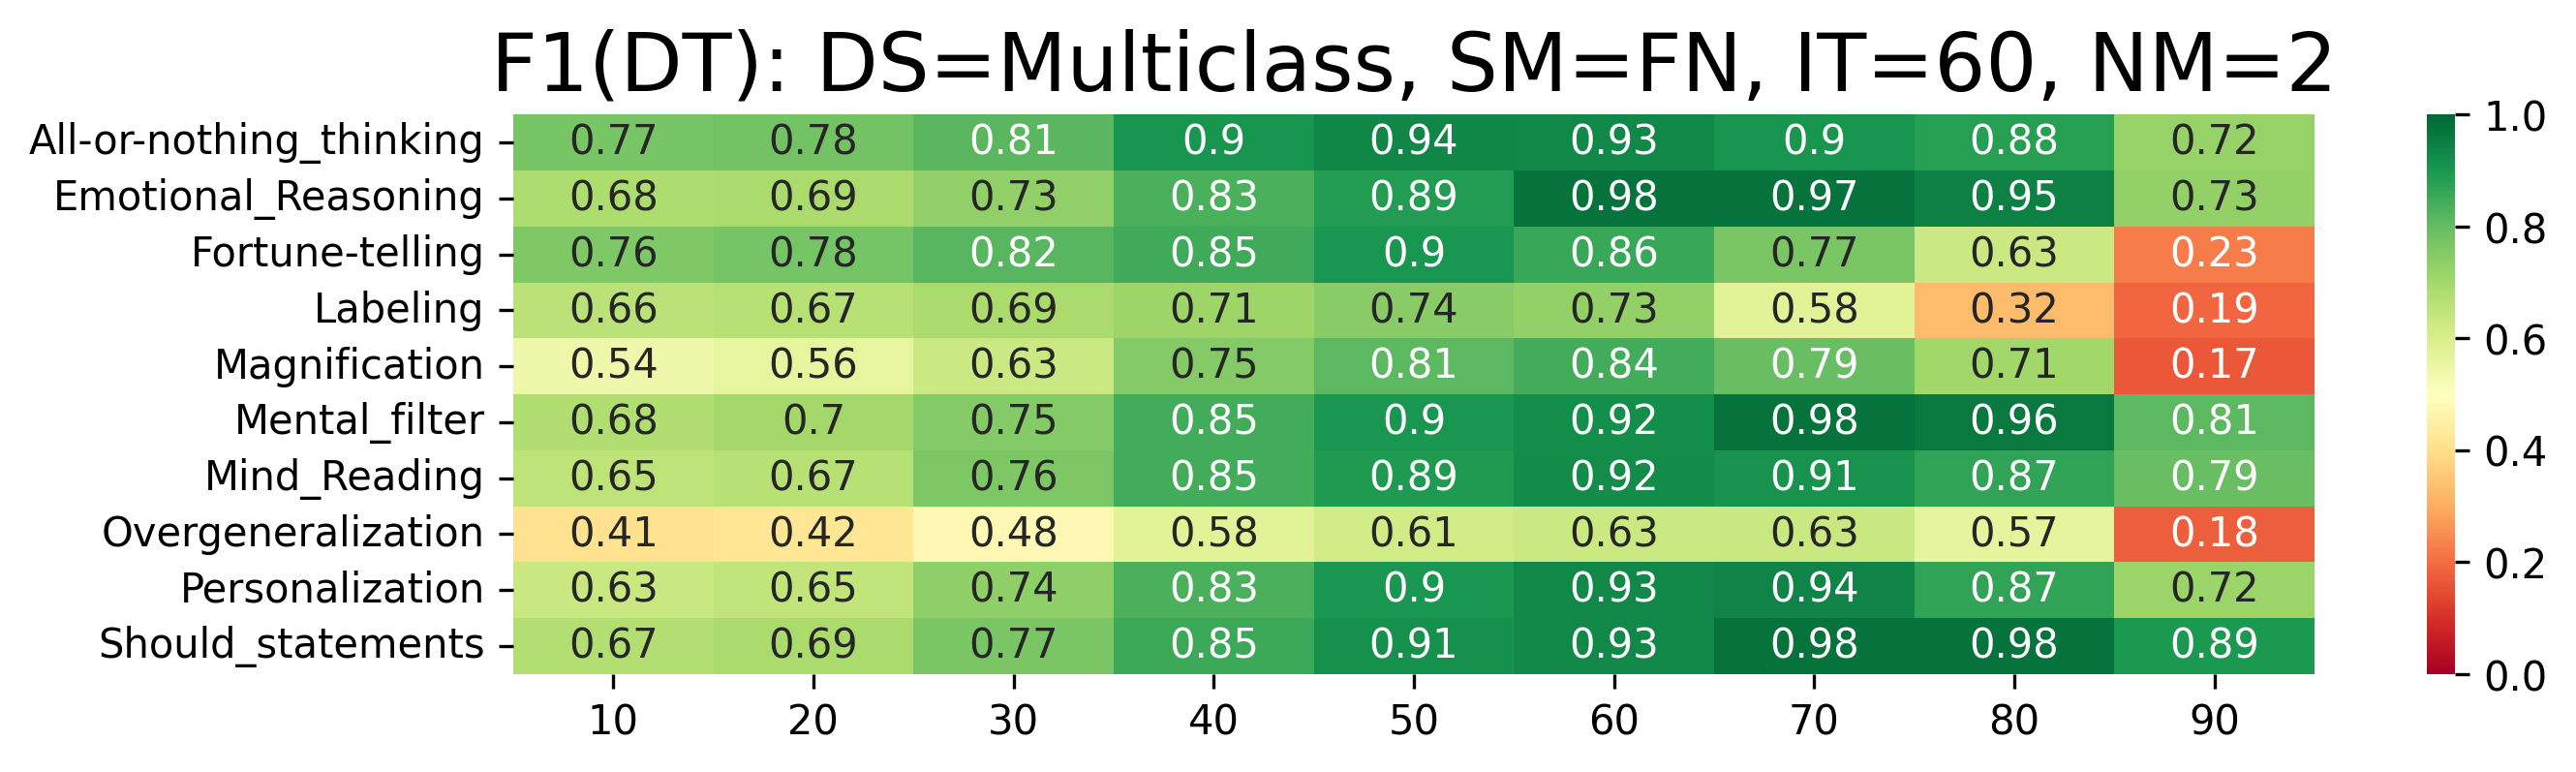

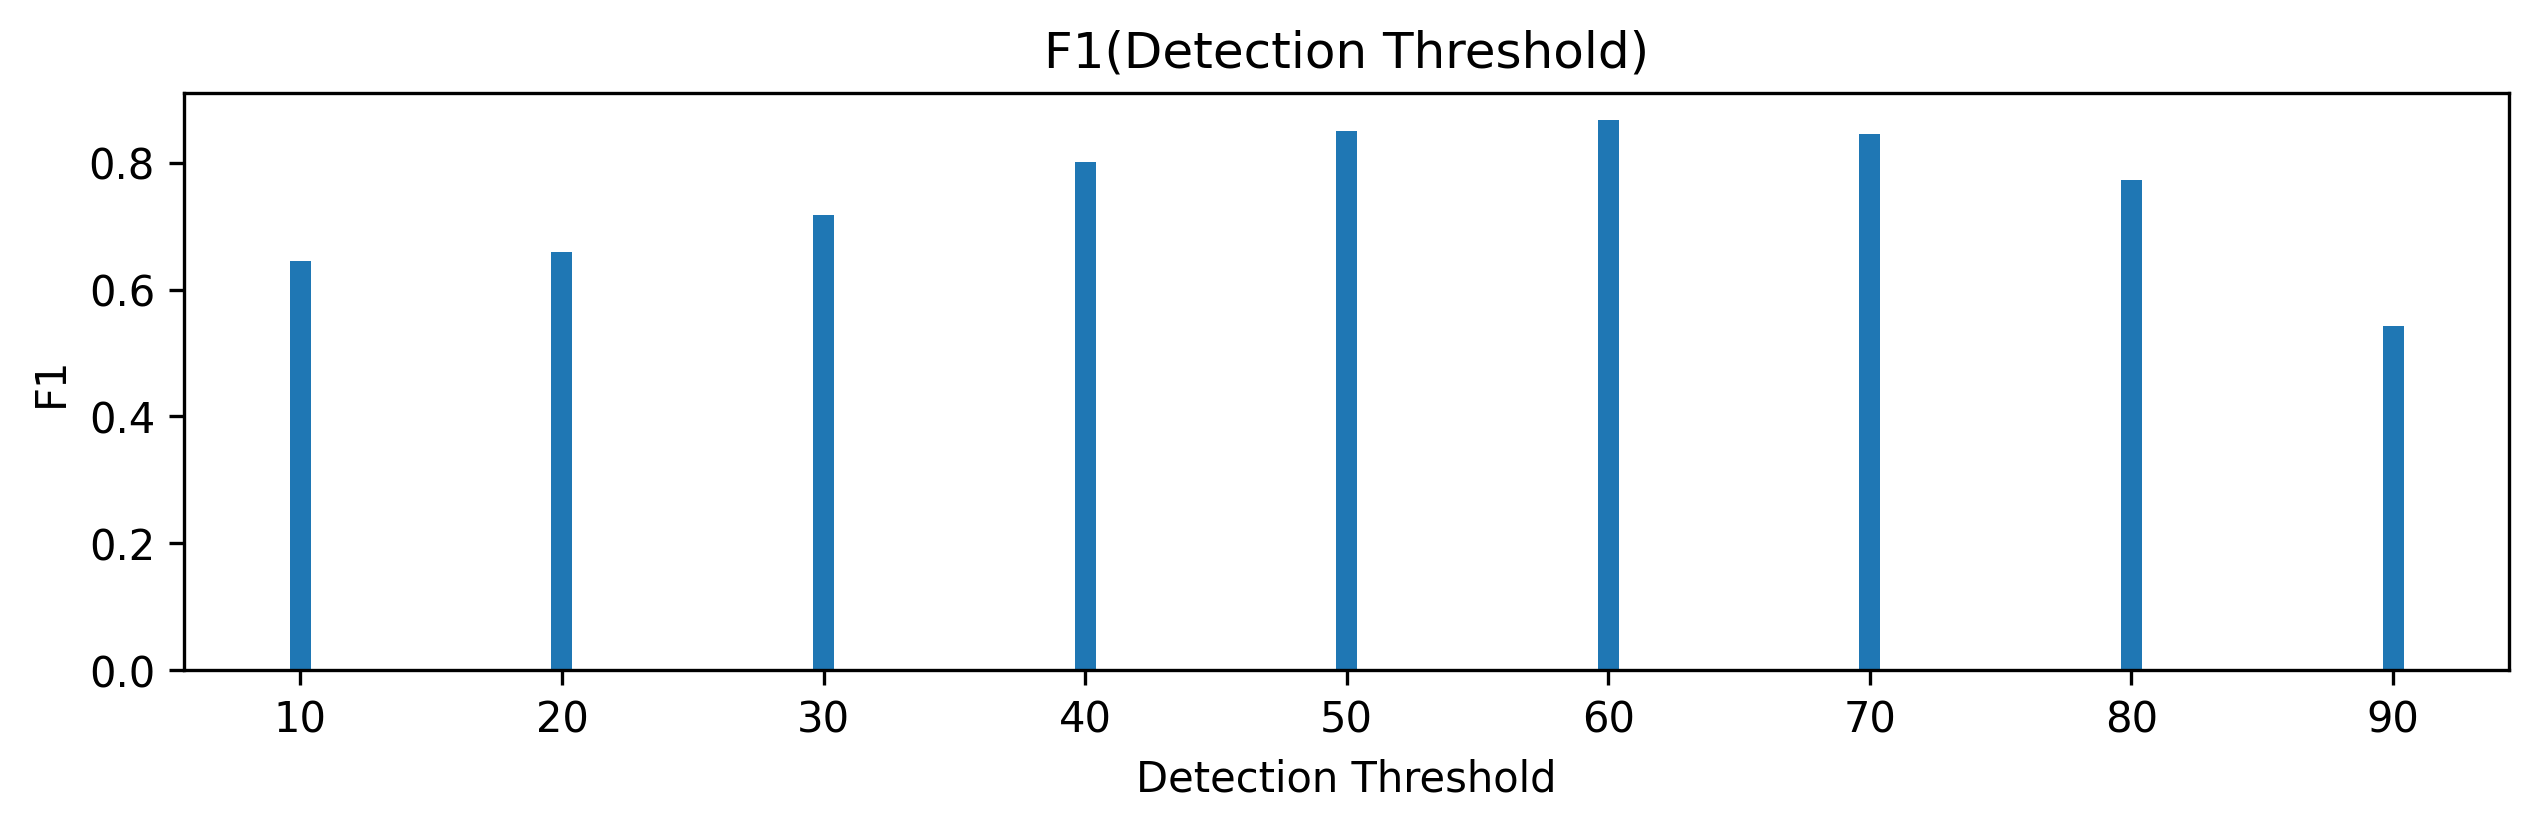

In [10]:
# Explore precison, recall and F1 for specific distortions with best NM, SM, and IT for range of DT 

shift = 0
full_test_circle(df,model_multiclass_path,f'{model_name}-{shift+1}',
                validation_fraction=5,inclusion_thresholds=[IT],
                detection_thresholds=detection_thresholds,n_max=NM, selection_metrics = [SM],
                weighted=True,all_scores=True,averages=True,split_shift=shift,evaluator=our_evaluator_top1)

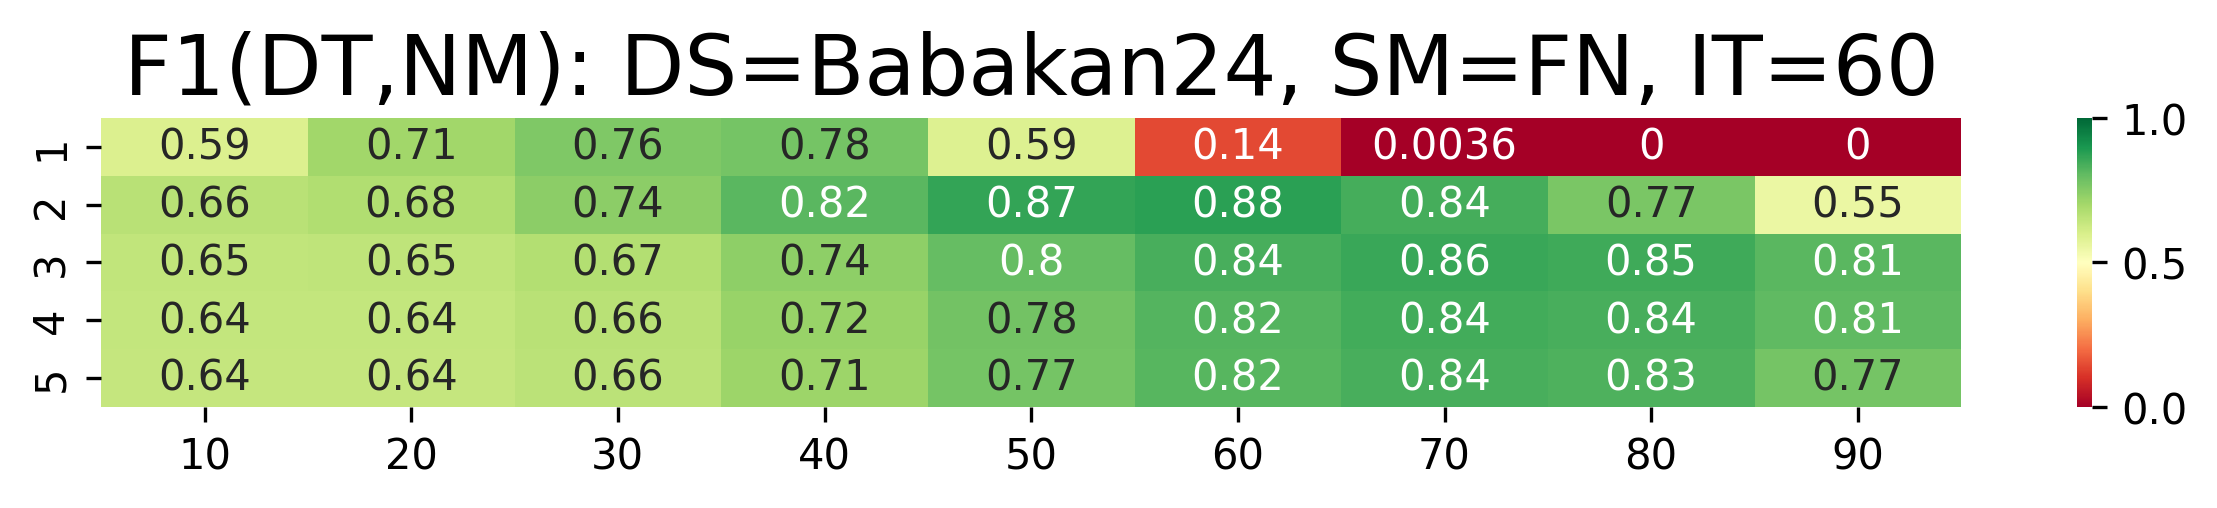

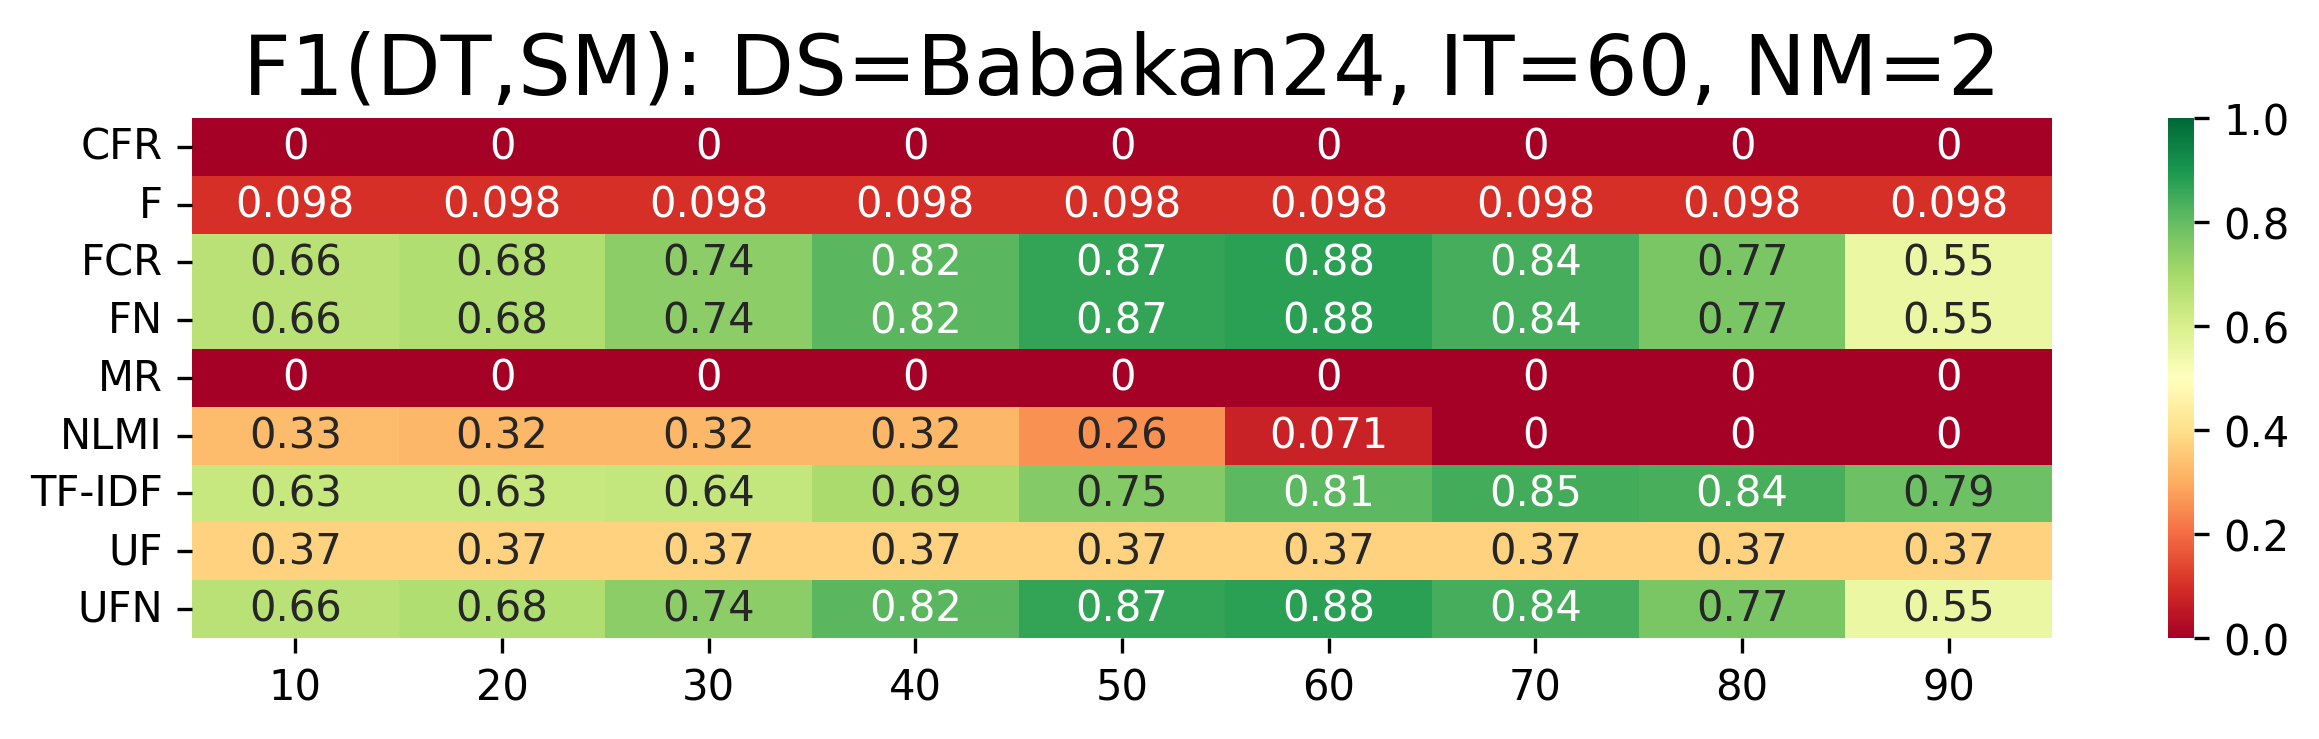

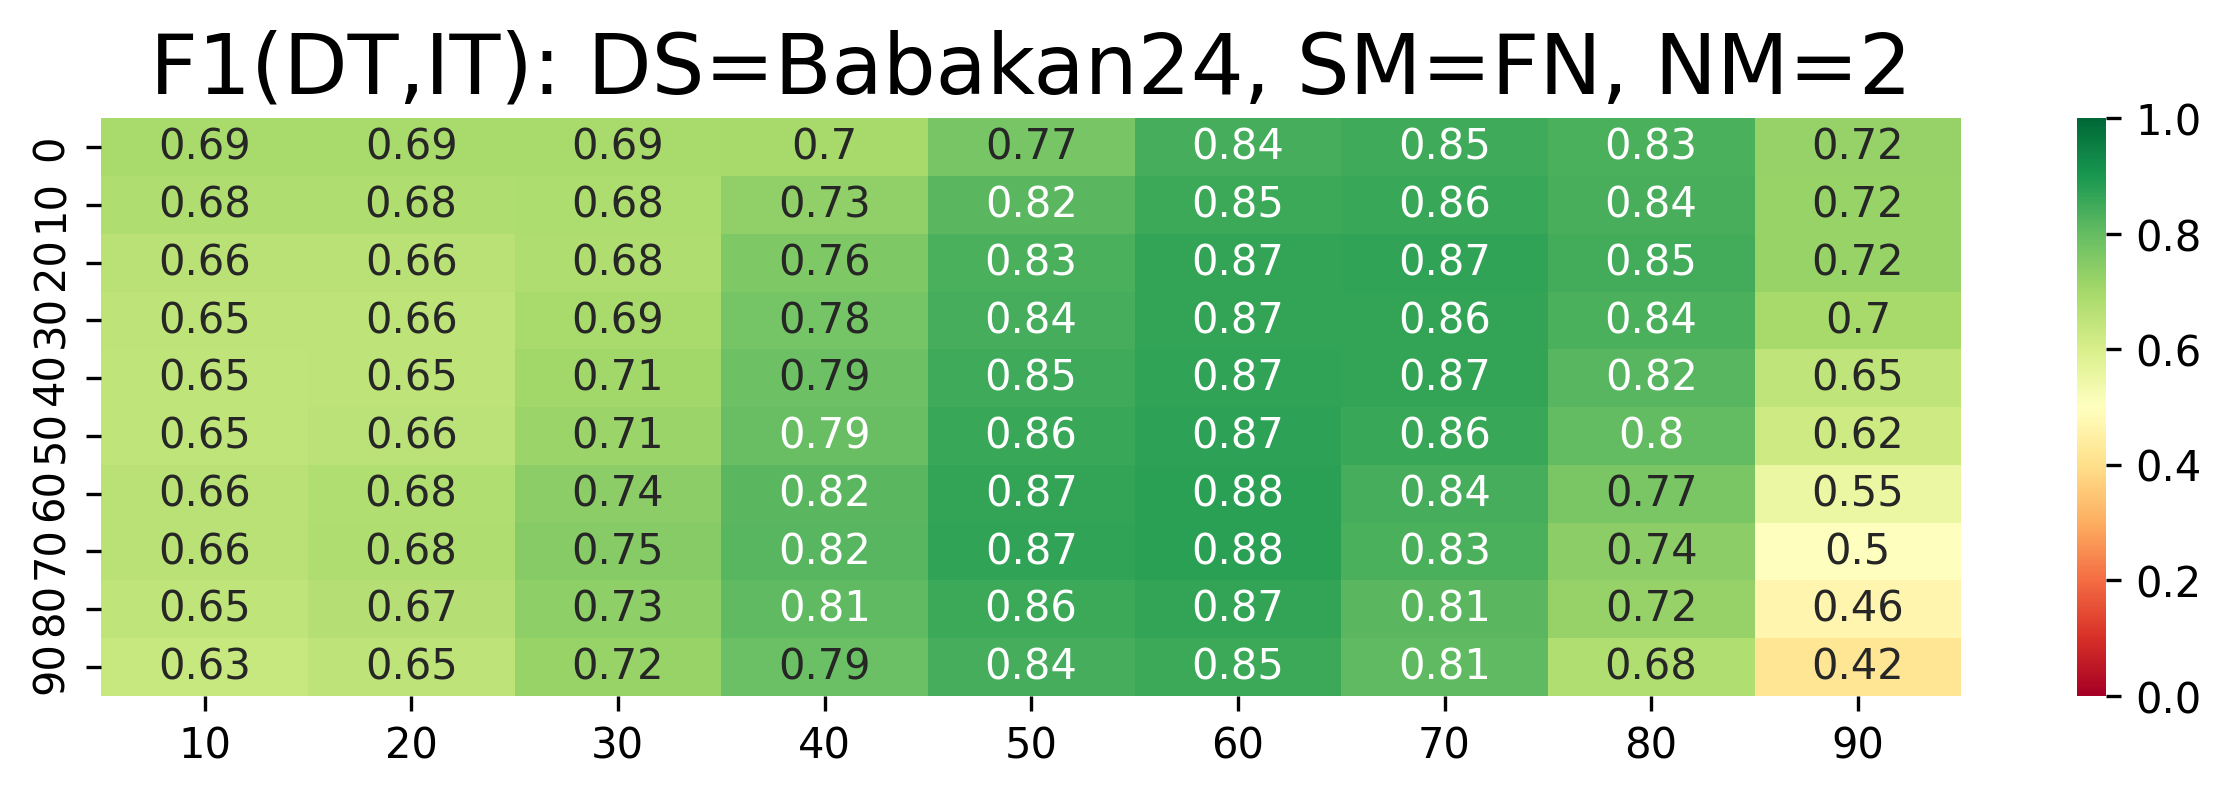

In [11]:
# Render average F1 scores for ranges of NM, SM, and IT and range of DT 

m = build_triple_matrix(summary_weighted,0,3,{2:SM,1:IT},6,n_max_values,detection_thresholds)
matrix_plot(n_max_values, detection_thresholds, m, 1.0, title = f'F1(DT,NM): DS={DS}, SM={SM}, IT={IT}', vmin = 0, vmax = 1.0, titlefontsize = 20, dpi = 300, width = 10)

m = build_triple_matrix(summary_weighted,2,3,{0:NM,1:IT},6,selection_metrics,detection_thresholds)
matrix_plot(sorted(selection_metrics), detection_thresholds, m, 1.0, title = f'F1(DT,SM): DS={DS}, IT={IT}, NM={NM}', vmin = 0, vmax = 1.0, titlefontsize = 20, dpi = 300, width = 10)

m = build_triple_matrix(summary_weighted,1,3,{0:NM,2:SM},6,inclusion_thresholds, detection_thresholds)
matrix_plot(sorted(inclusion_thresholds), detection_thresholds, m, 1.0, title = f'F1(DT,IT): DS={DS}, SM={SM}, NM={NM}', vmin = 0, vmax = 1.0, titlefontsize = 20, dpi = 300, width = 10)


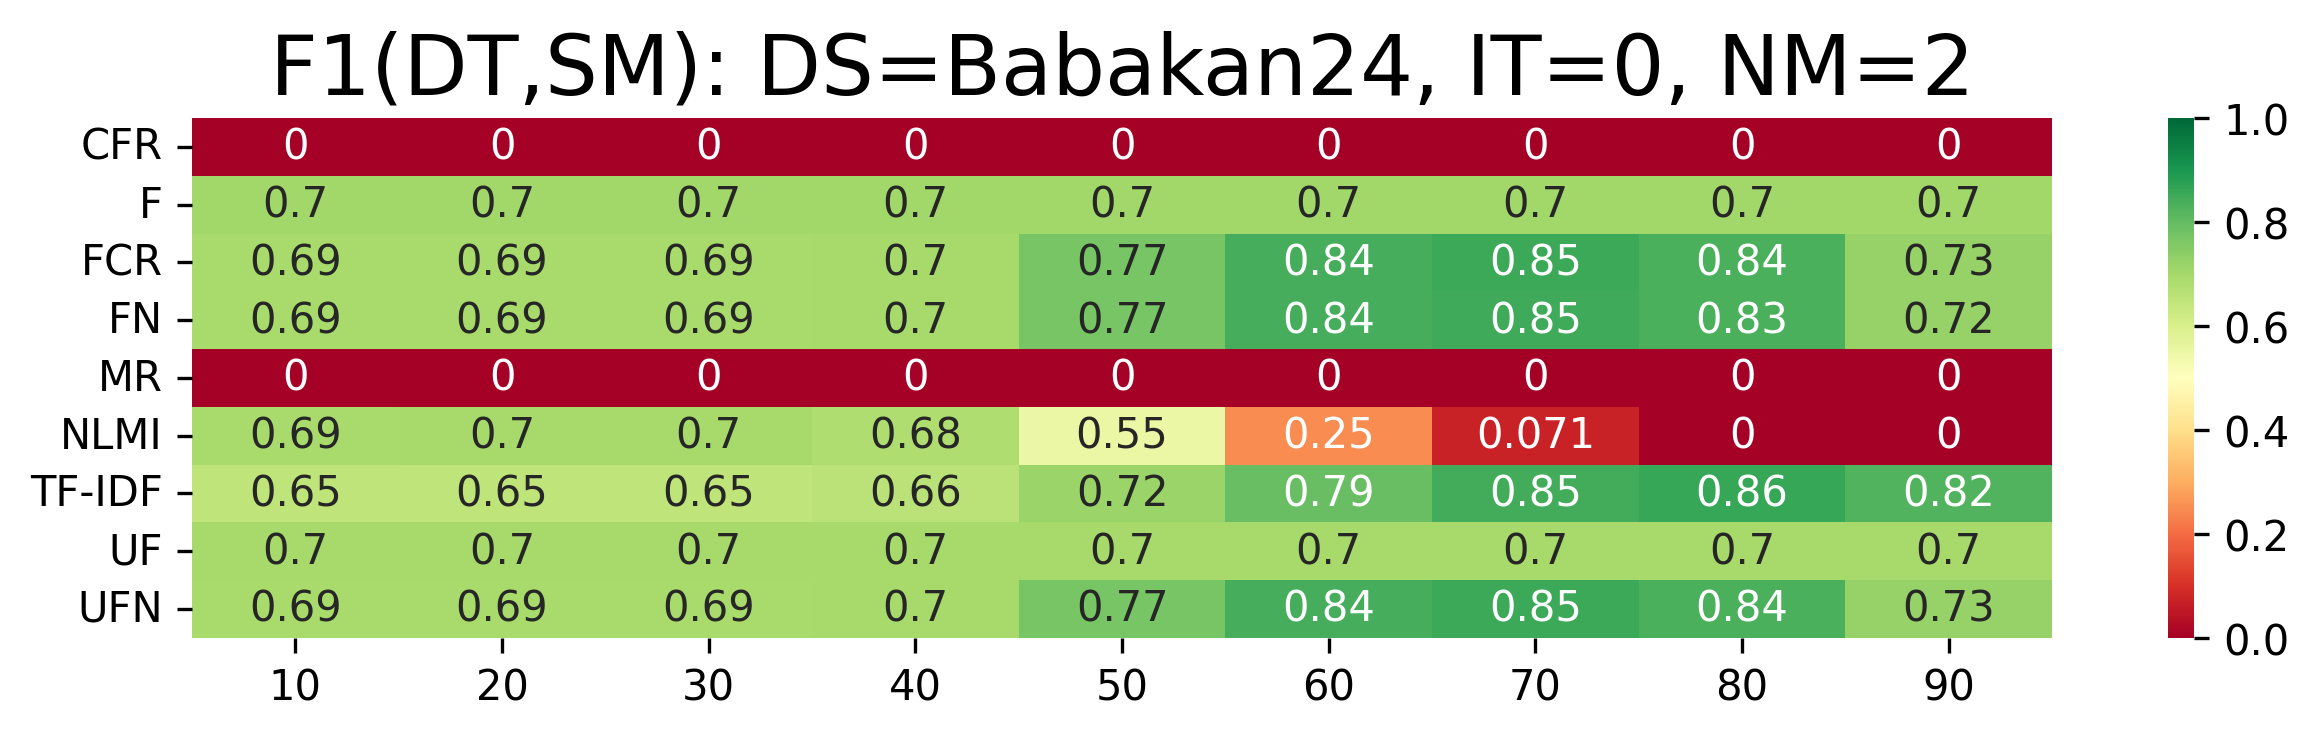

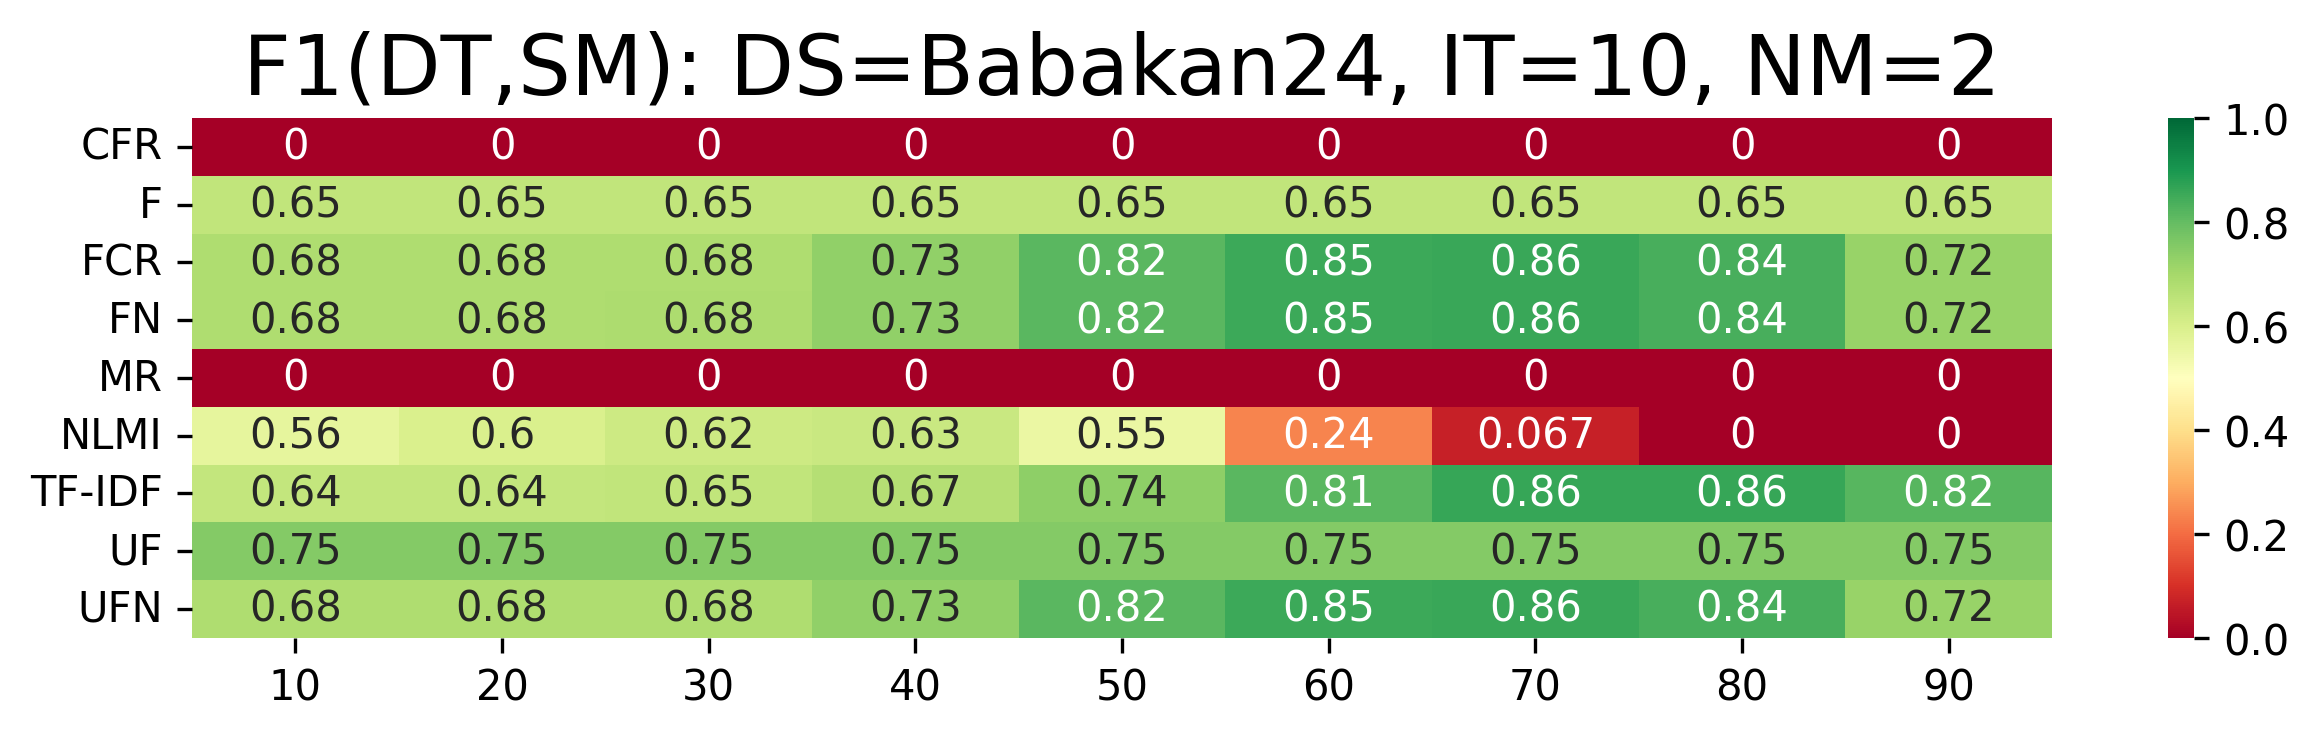

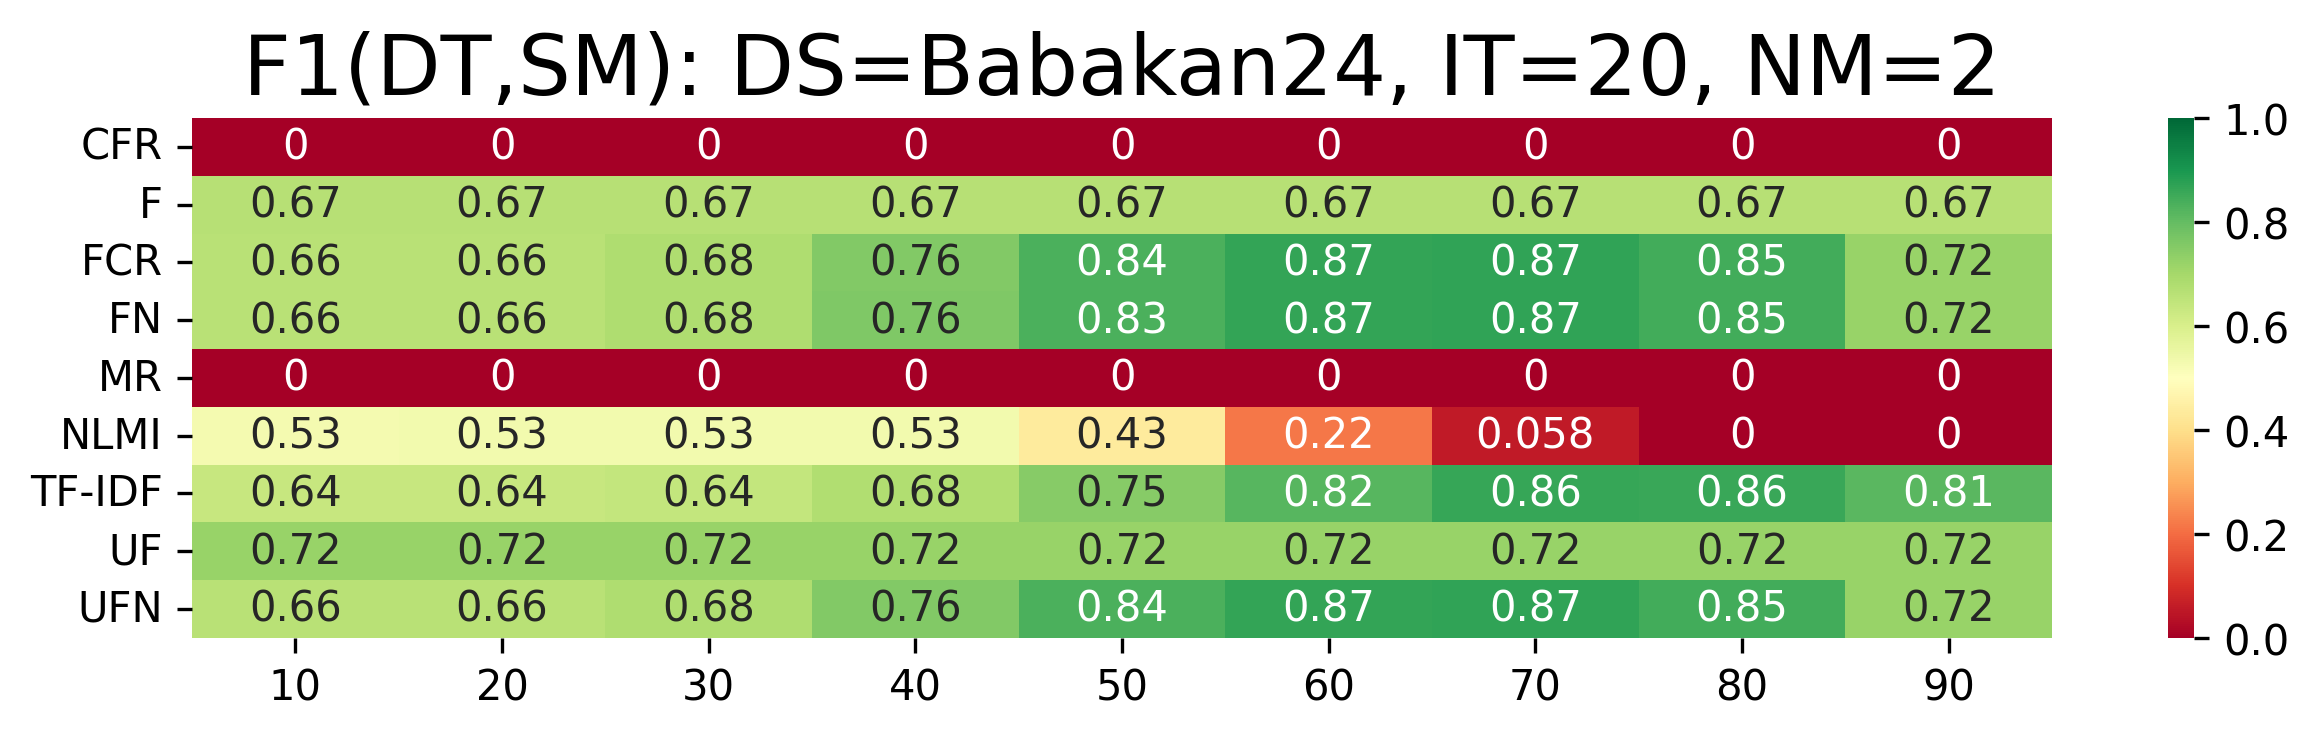

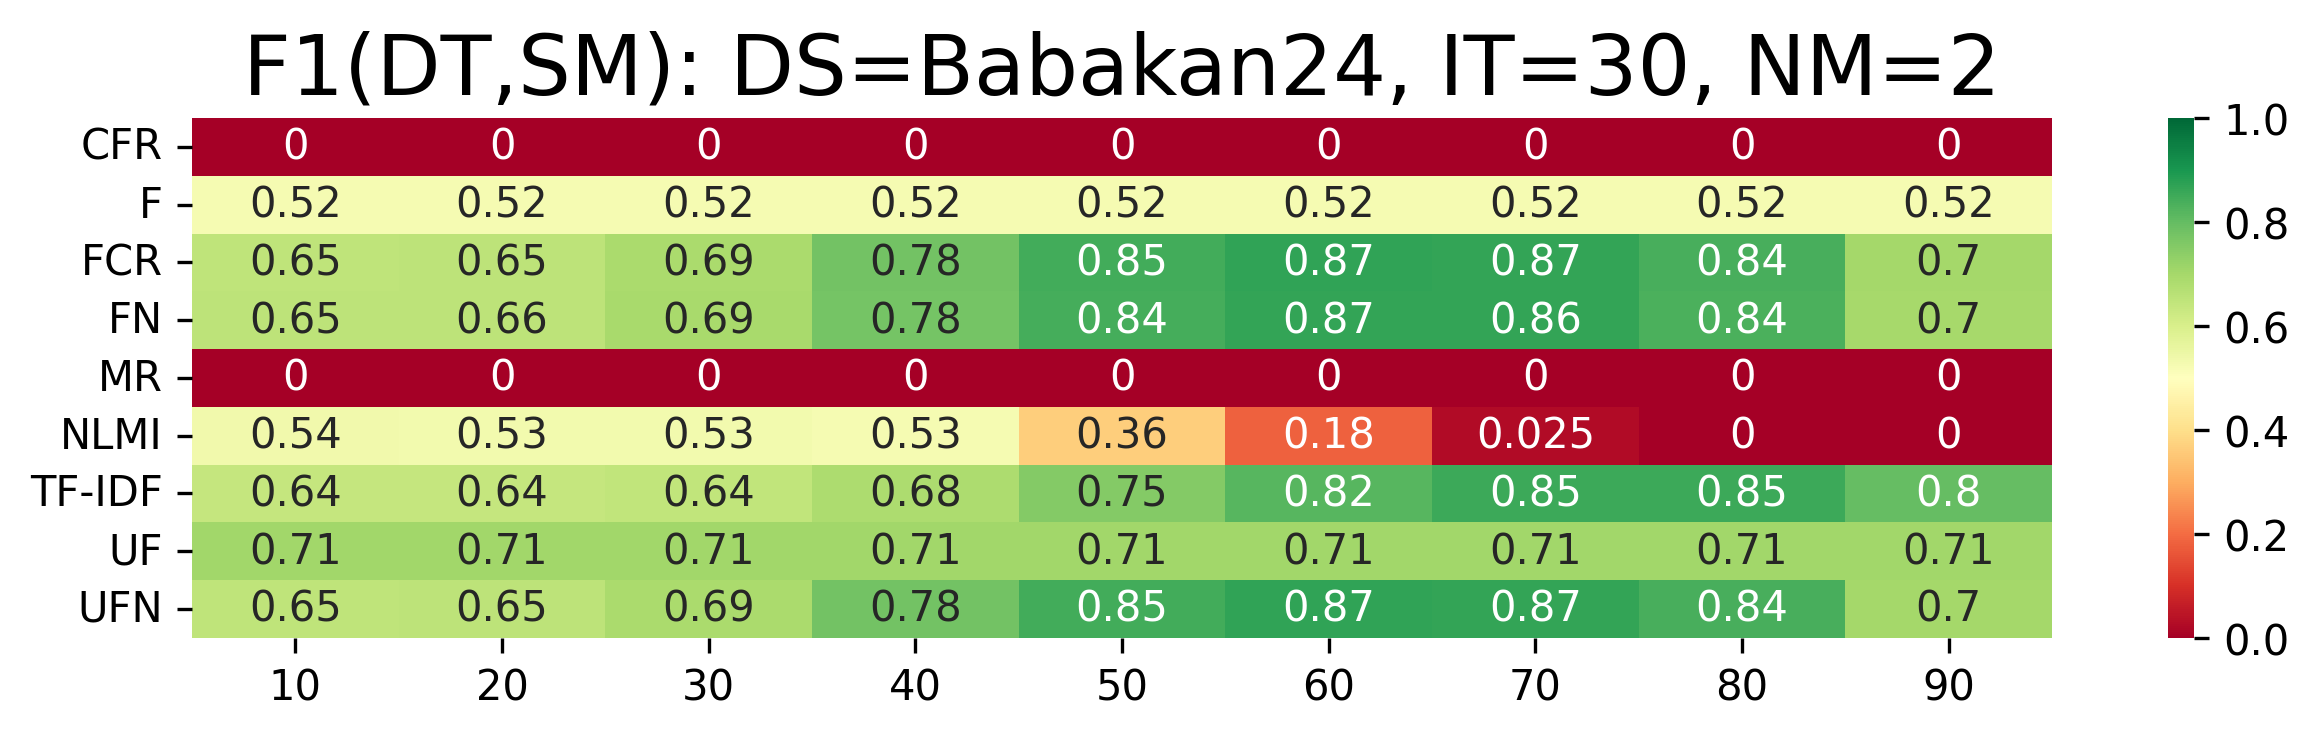

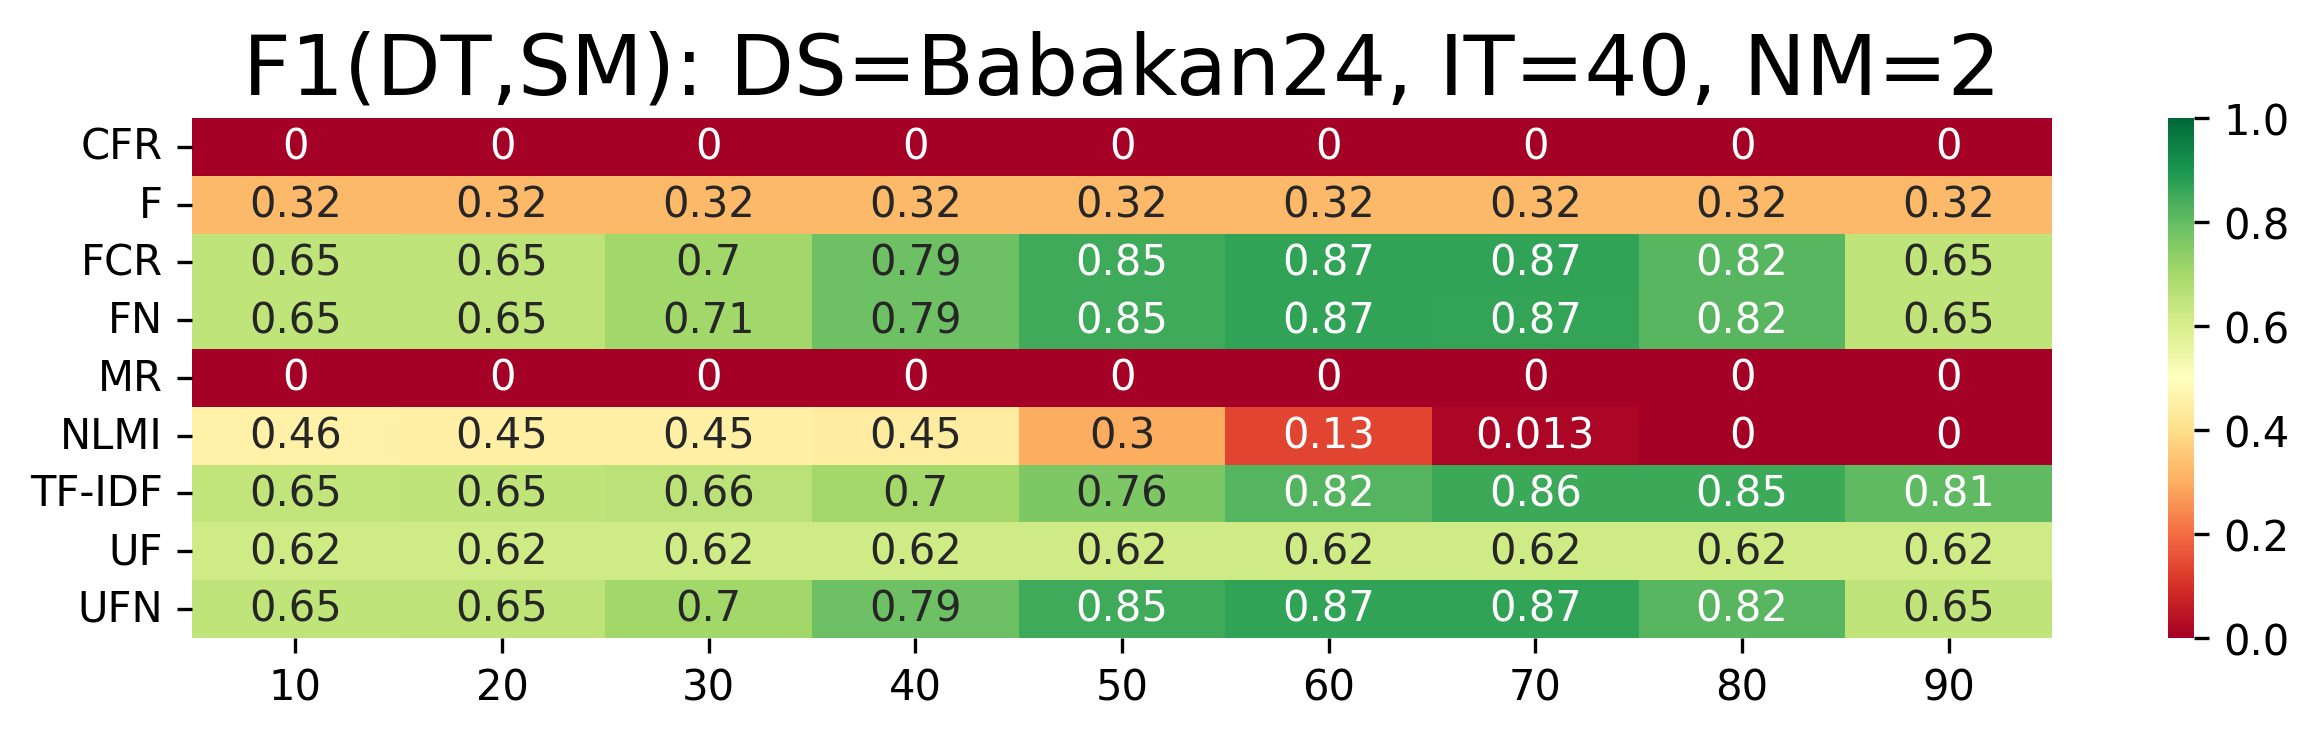

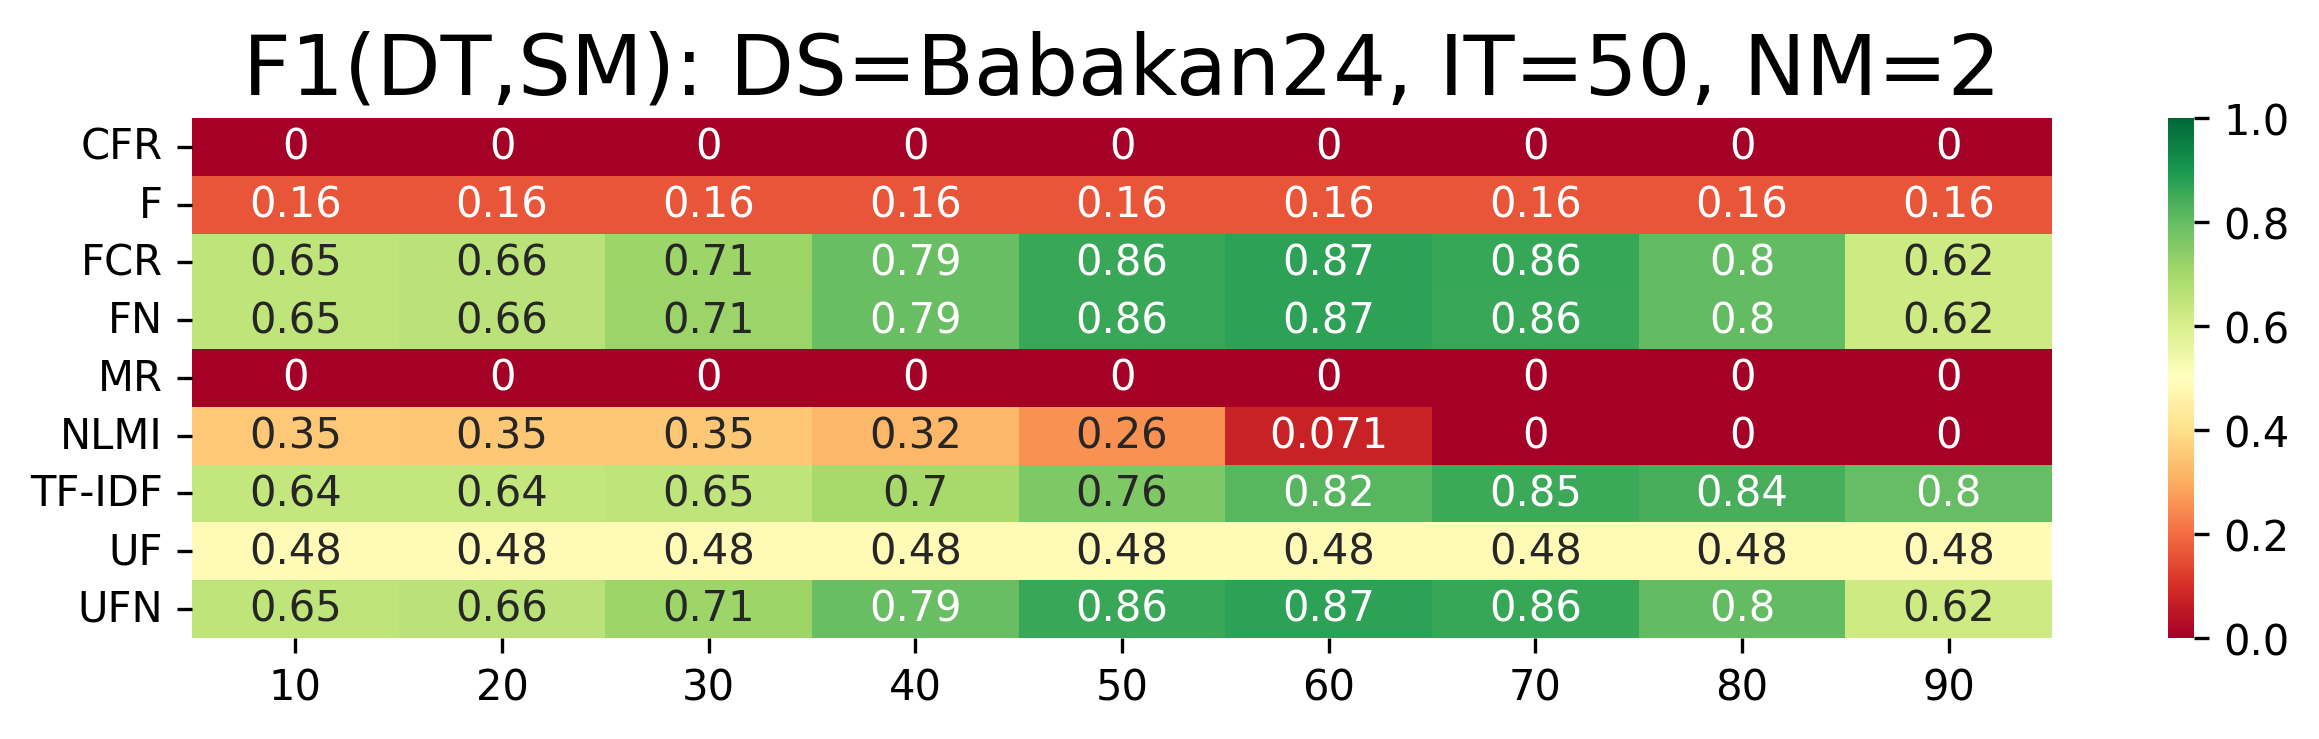

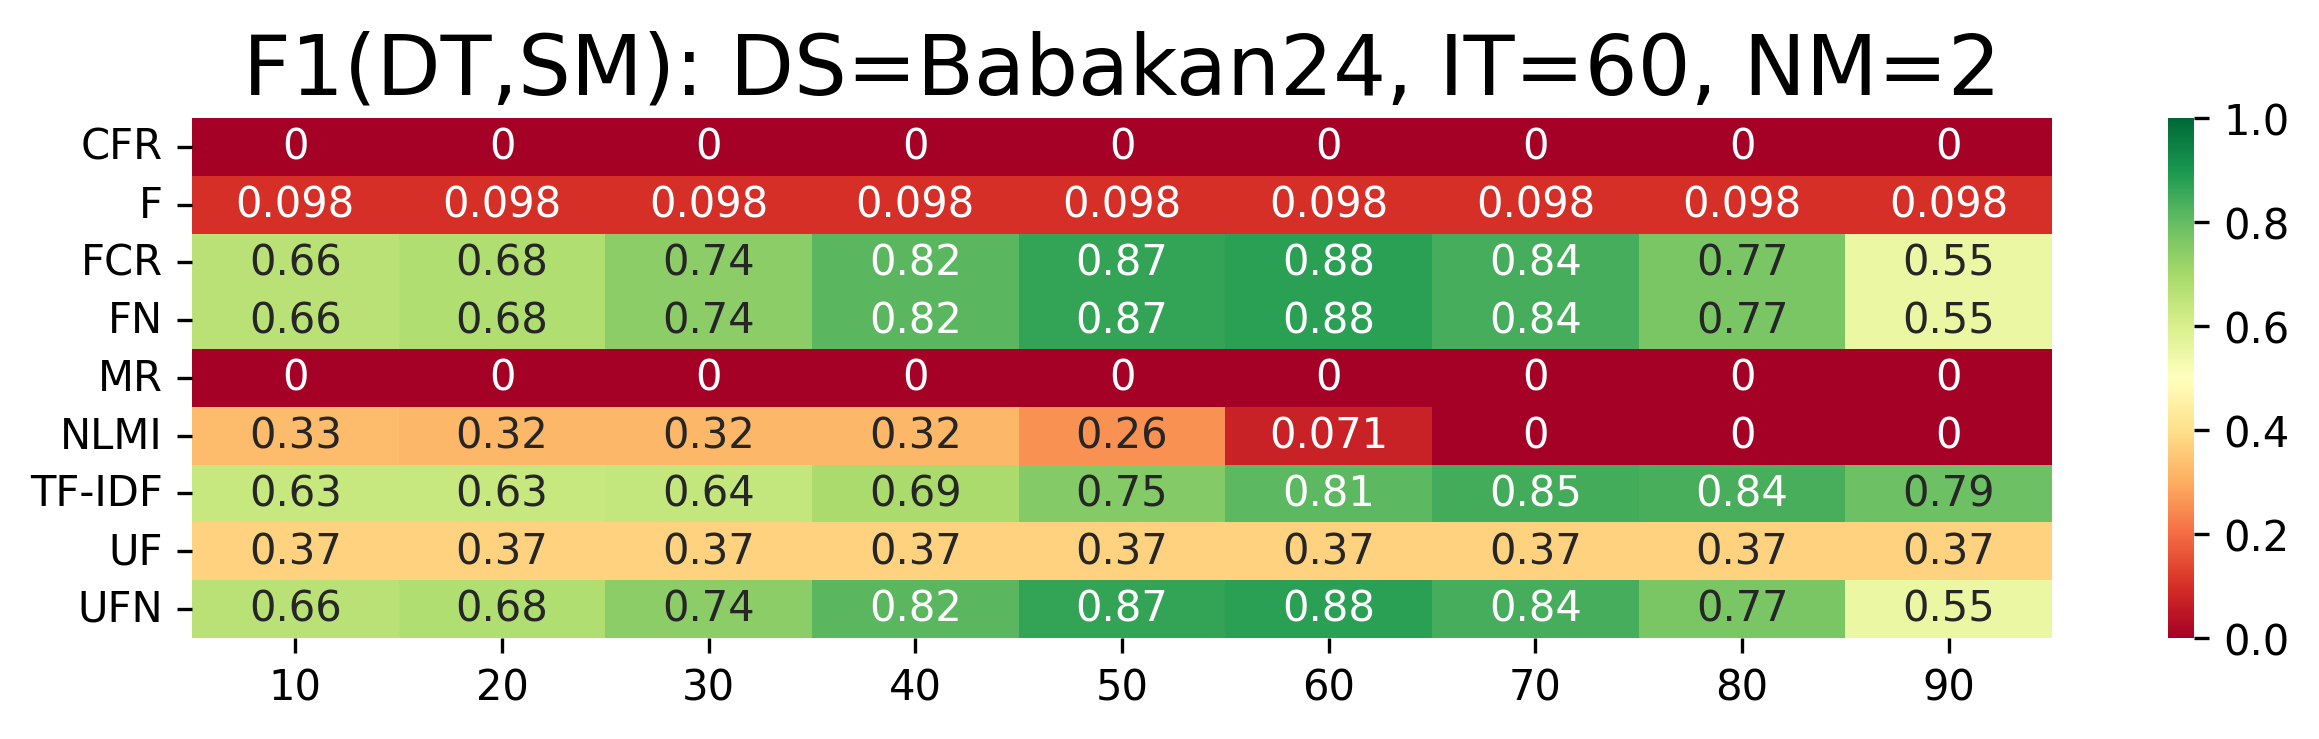

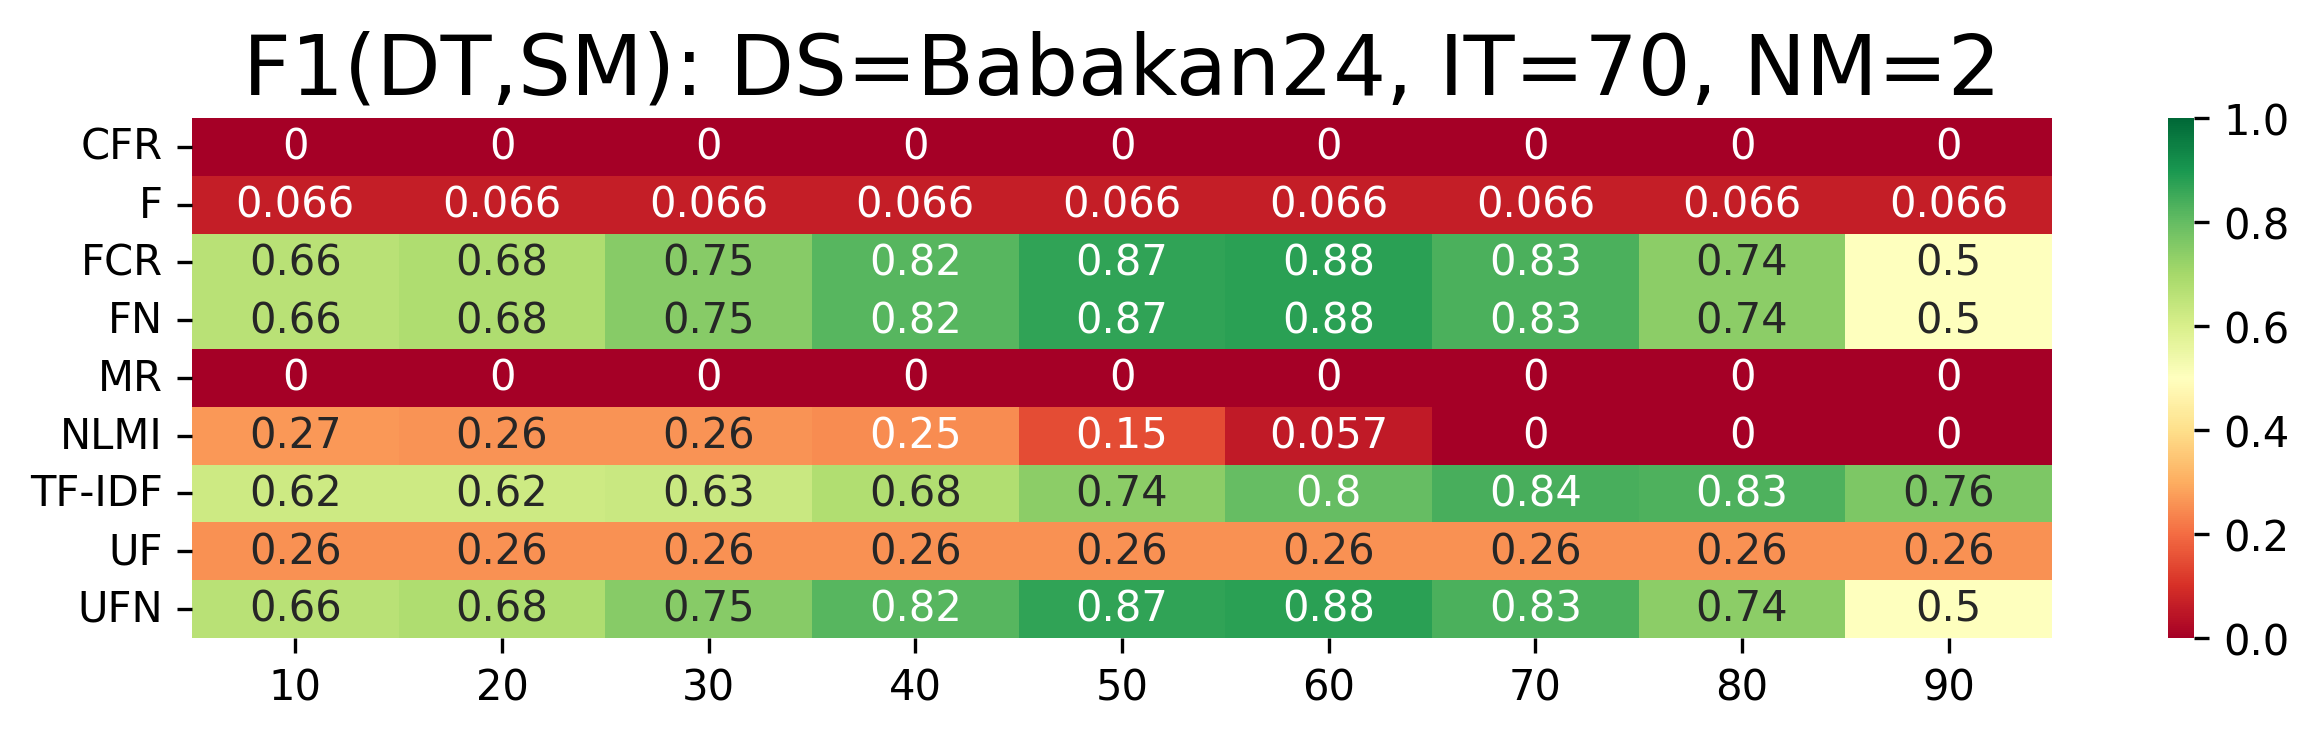

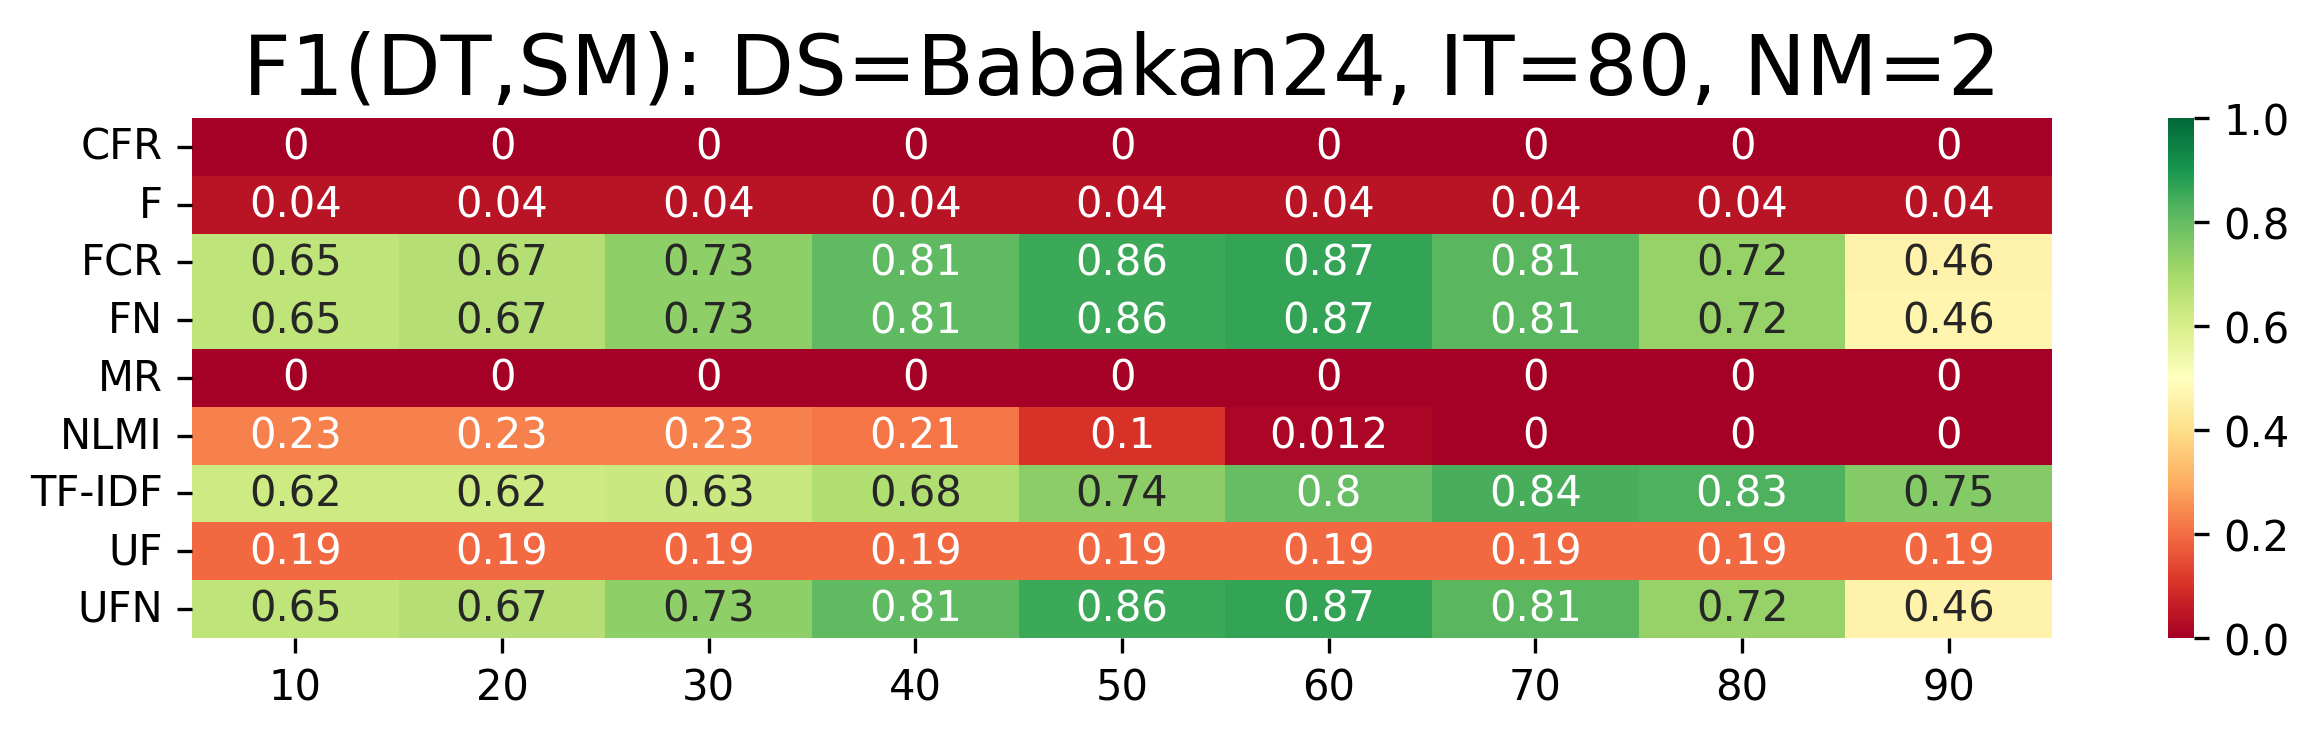

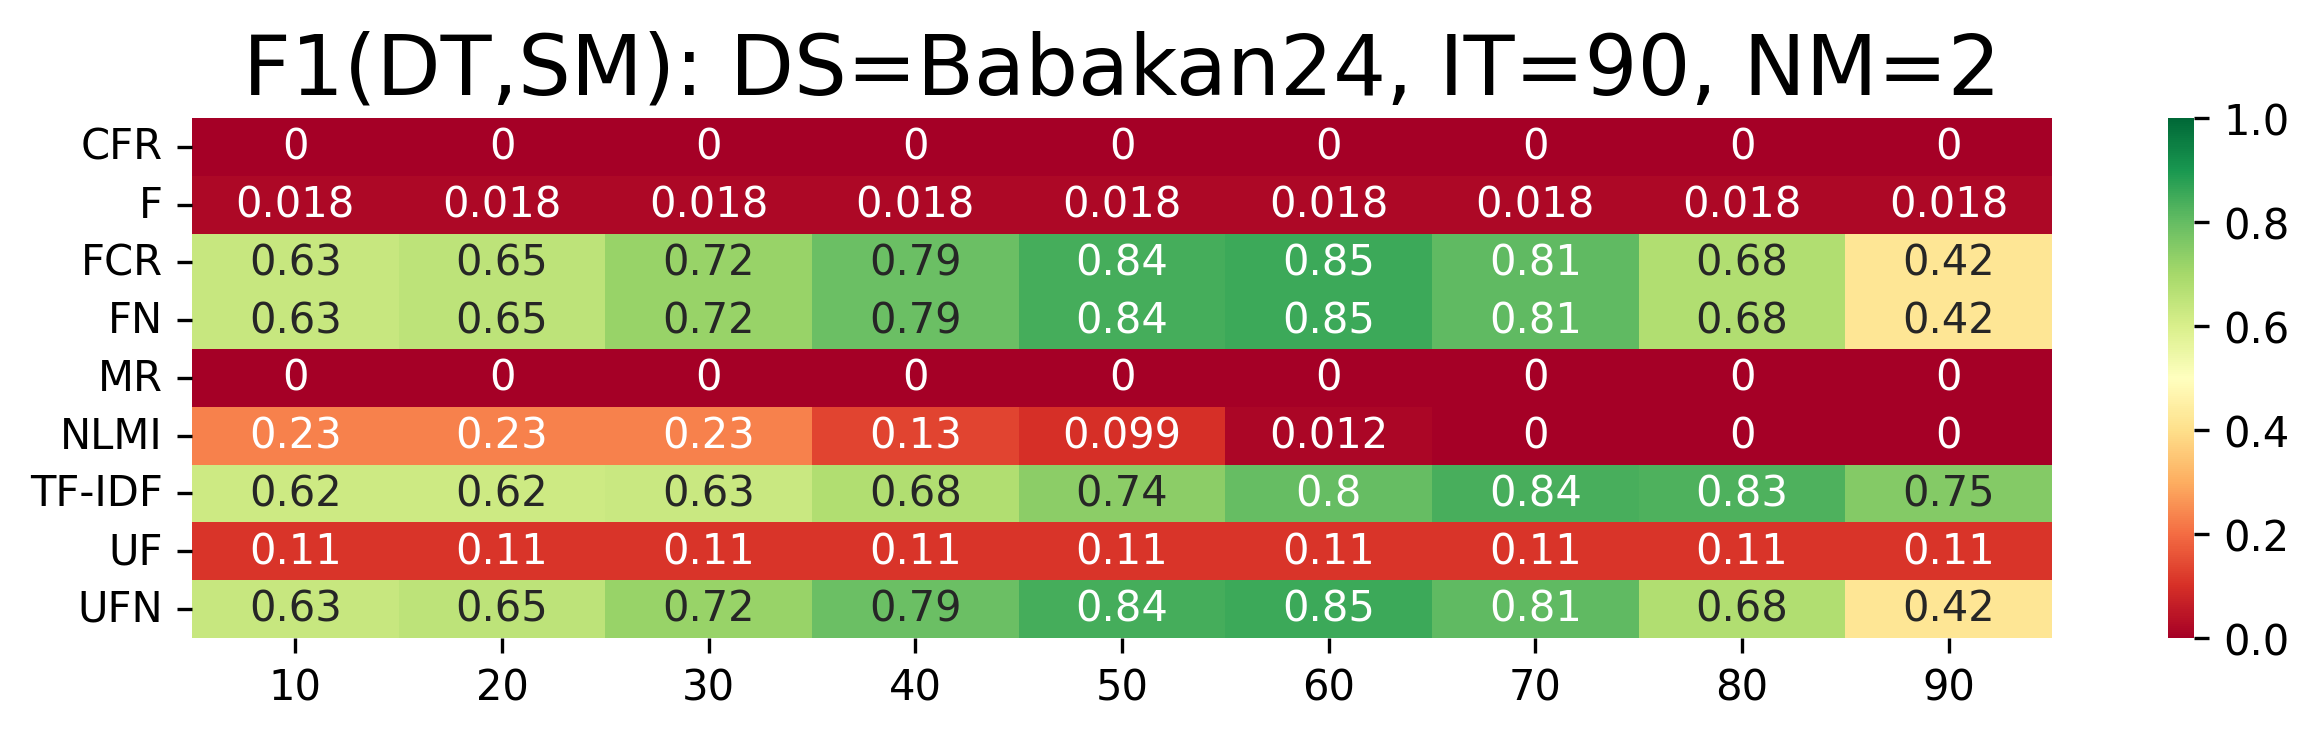

In [12]:
# Visualize how different SM perform with different IT and DT

for it in inclusion_thresholds:
    m = build_triple_matrix(summary_weighted,2,3,{0:NM,1:it},6,selection_metrics,detection_thresholds)
    matrix_plot(sorted(selection_metrics), detection_thresholds, m, 1.0, title = f'F1(DT,SM): DS={DS}, IT={it}, NM={NM}', vmin = 0, vmax = 1.0, titlefontsize = 20, dpi = 300, width = 10)


## Summary

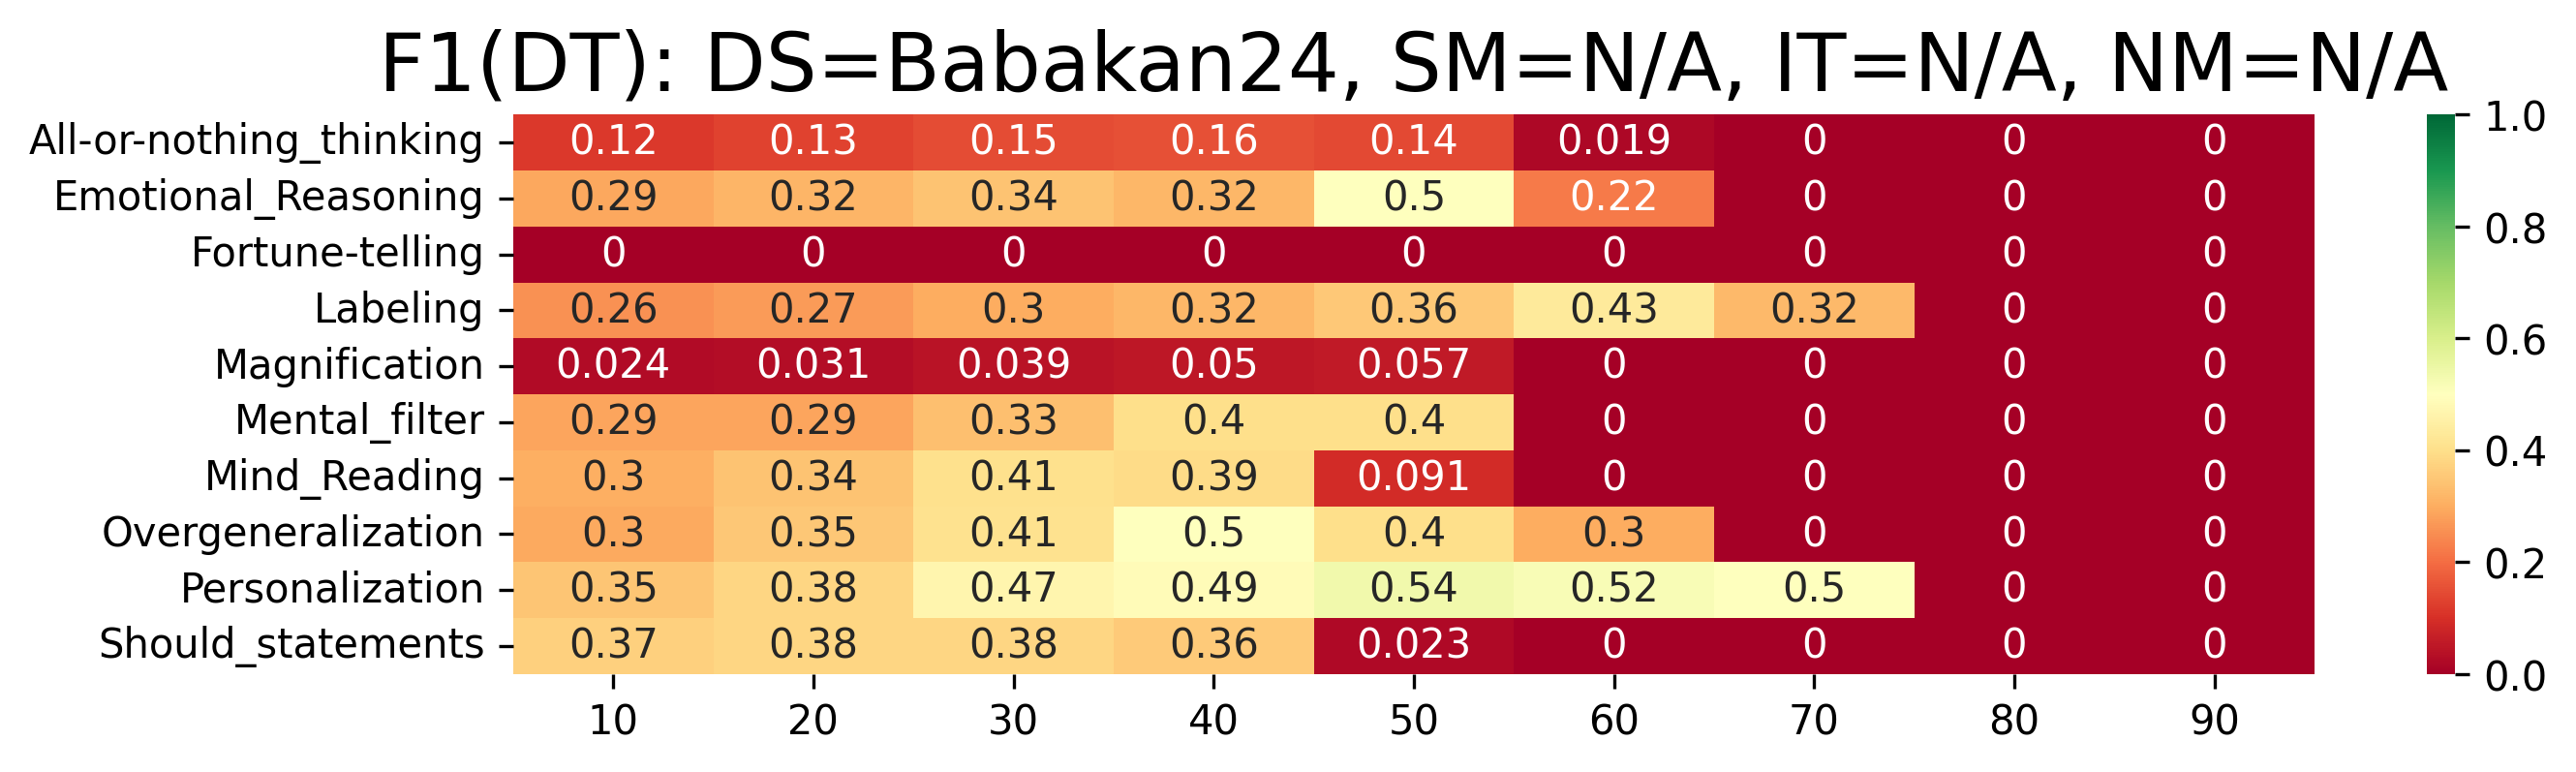

('N/A', 'N/A', 'N/A', 40, 0.29852150491406354, {'All-or-nothing_thinking': 0.15537848605577687, 'Emotional_Reasoning': 0.32, 'Fortune-telling': 0, 'Labeling': 0.31967213114754106, 'Magnification': 0.05, 'Mental_filter': 0.4, 'Mind_Reading': 0.39285714285714285, 'Overgeneralization': 0.5, 'Personalization': 0.4880952380952381, 'Should_statements': 0.3592120509849363})
['All-or-nothing_thinking', 'Emotional_Reasoning', 'Fortune-telling', 'Labeling', 'Magnification', 'Mental_filter', 'Mind_Reading', 'Overgeneralization', 'Personalization', 'Should_statements']
[0.16, 0.32, 0, 0.32, 0.05, 0.4, 0.39, 0.5, 0.49, 0.36]


In [13]:
# Paper section: "Results and Discussion"

# Evaluate baseline model (Arinicheva and Kolonin 2025) without splits

all_metricsmap = {'All-or-nothing_thinking':'dichotomous-reasoning',
              'Fortune-telling':'fortune-telling',
              'Mental_filter':'mental-filtering',
              'Overgeneralization':'overgeneralizing',
              'Labeling':'labeling',
              'Mind_Reading':'mindreading',
              'Personalization':'personalizing',
              'Emotional_Reasoning':'emotional-reasoning',
              'Magnification':'magnification',
              'Should_statements':'should-statement'}

def language_metrics(lang,metrics_filenames,path):
    metrics = {}
    for m in metrics_filenames:
        filename = metrics_filenames[m] if type(metrics_filenames) == dict else m
        metrics[m] = path + lang + '/' + filename + '.txt'
    return metrics

tm_base = TextMetrics(language_metrics('',all_metricsmap,path='../../data/models/distortions/ours')
                  ,encoding="utf-8",metric_logarithmic=True,debug=False)

detection_thresholds = [10,20,30,40,50,60,70,80,90]

accumulator = []
evaluate_metrics(tm_base, df, 'N/A', detection_thresholds, DS, list(all_metricsmap), n_max='N/A', 
                selection_metric = 'N/A', f1_score=True, evaluator=our_evaluator_top1, accumulator=accumulator)

best = sorted(accumulator, key=lambda x: (-x[4]))[0]
print(best)
labels = sorted(list(best[5]))
print(labels)
numbers_arinicheva = [round(best[5][label],2) for label in labels]
print(numbers_arinicheva)

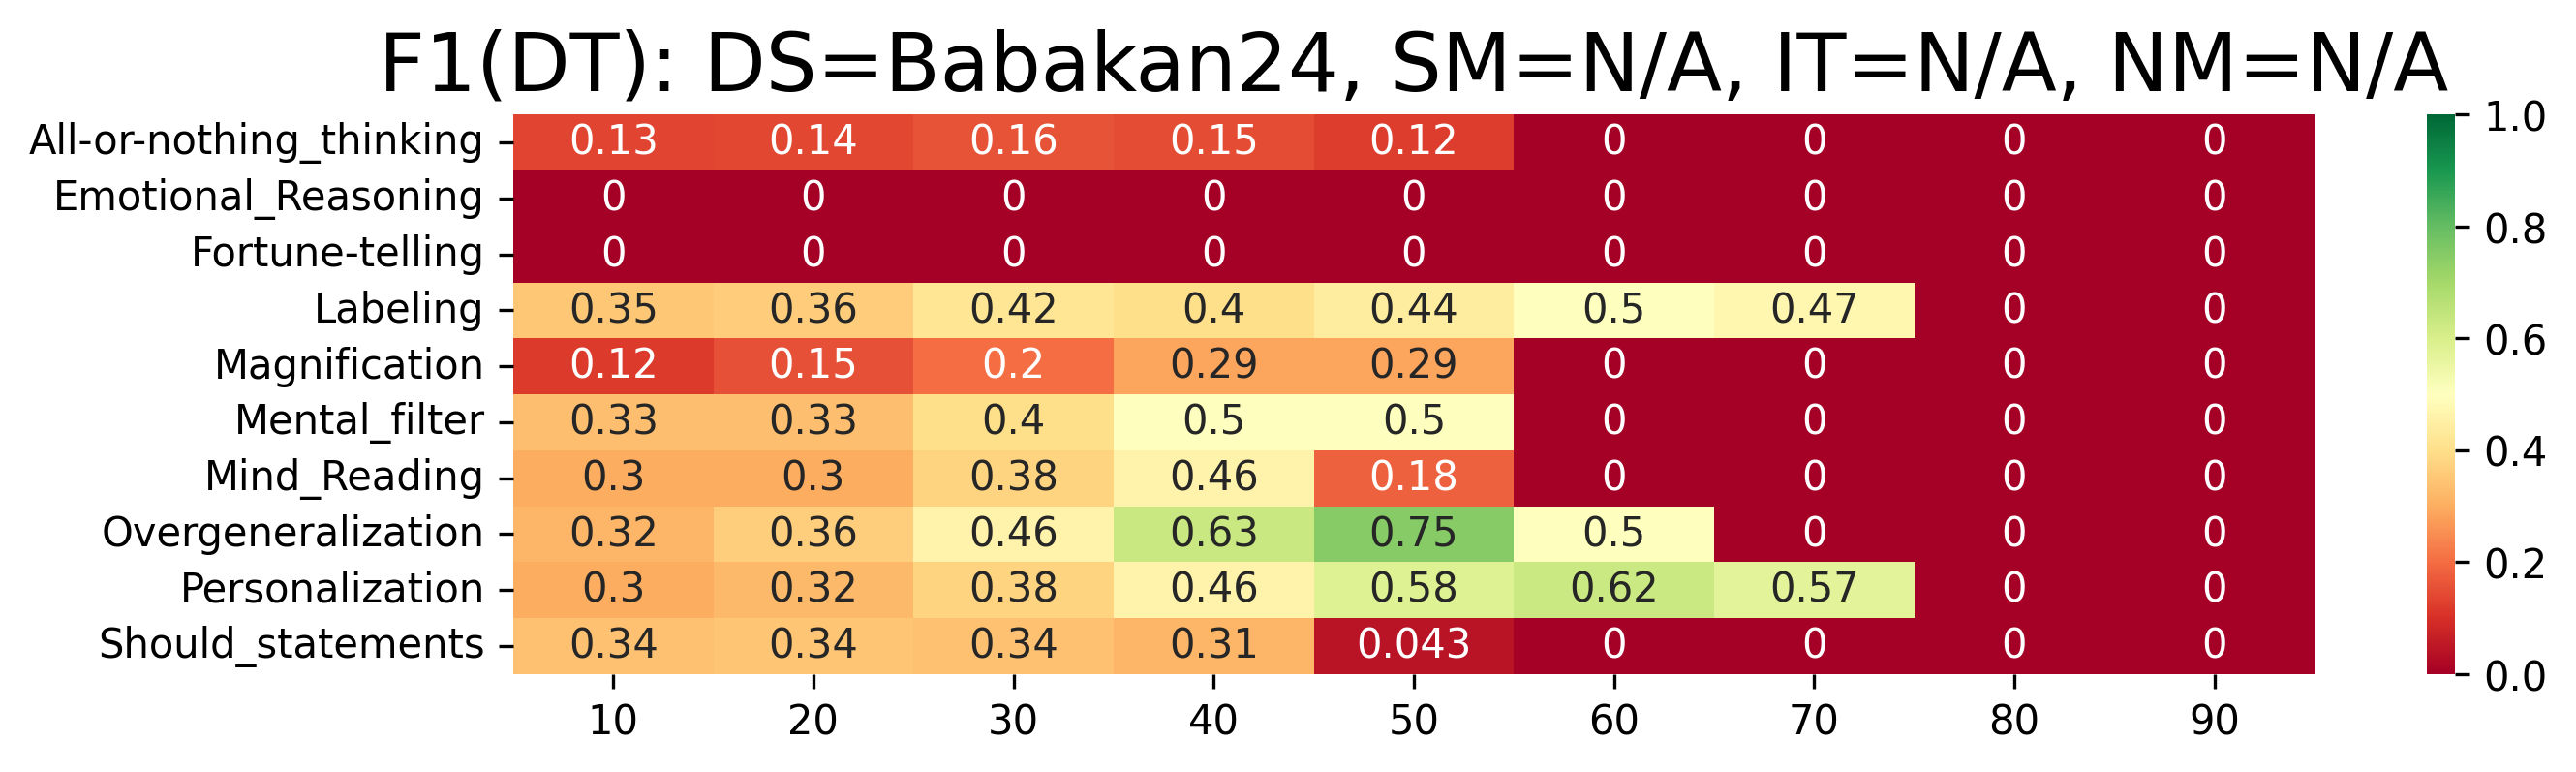

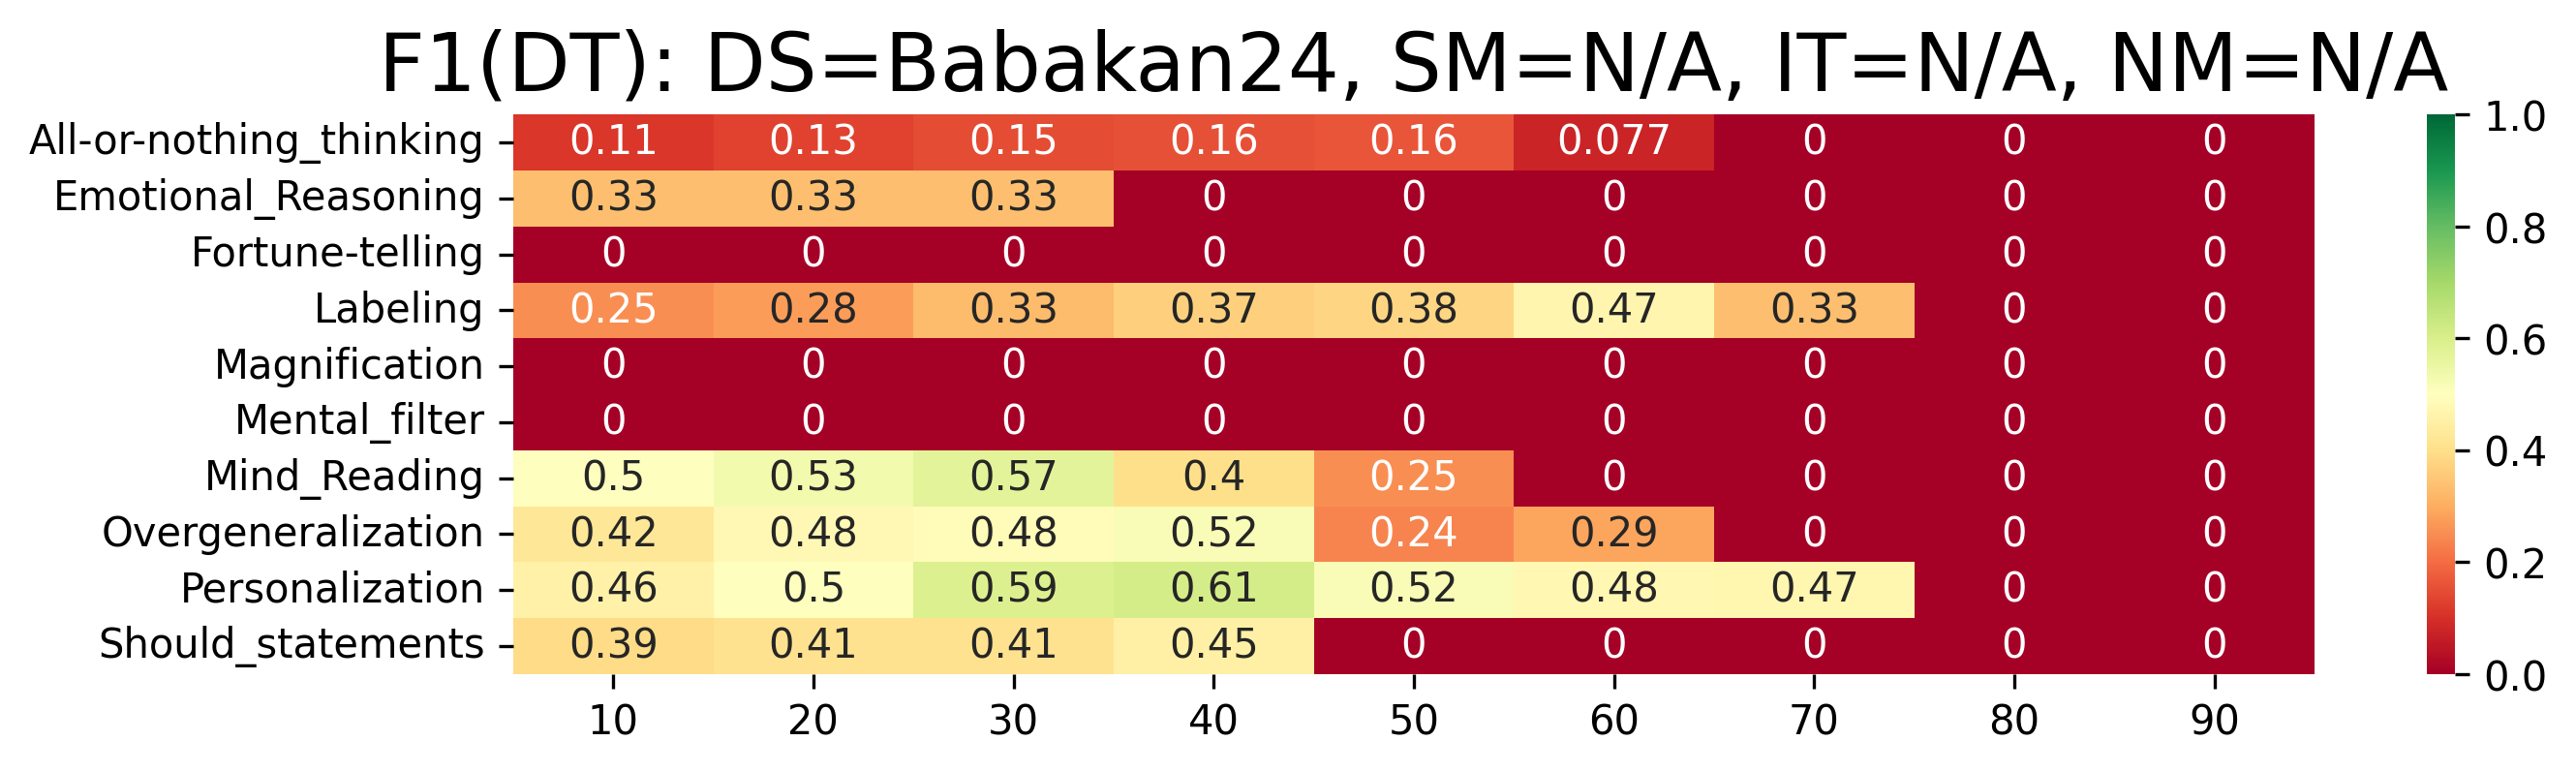

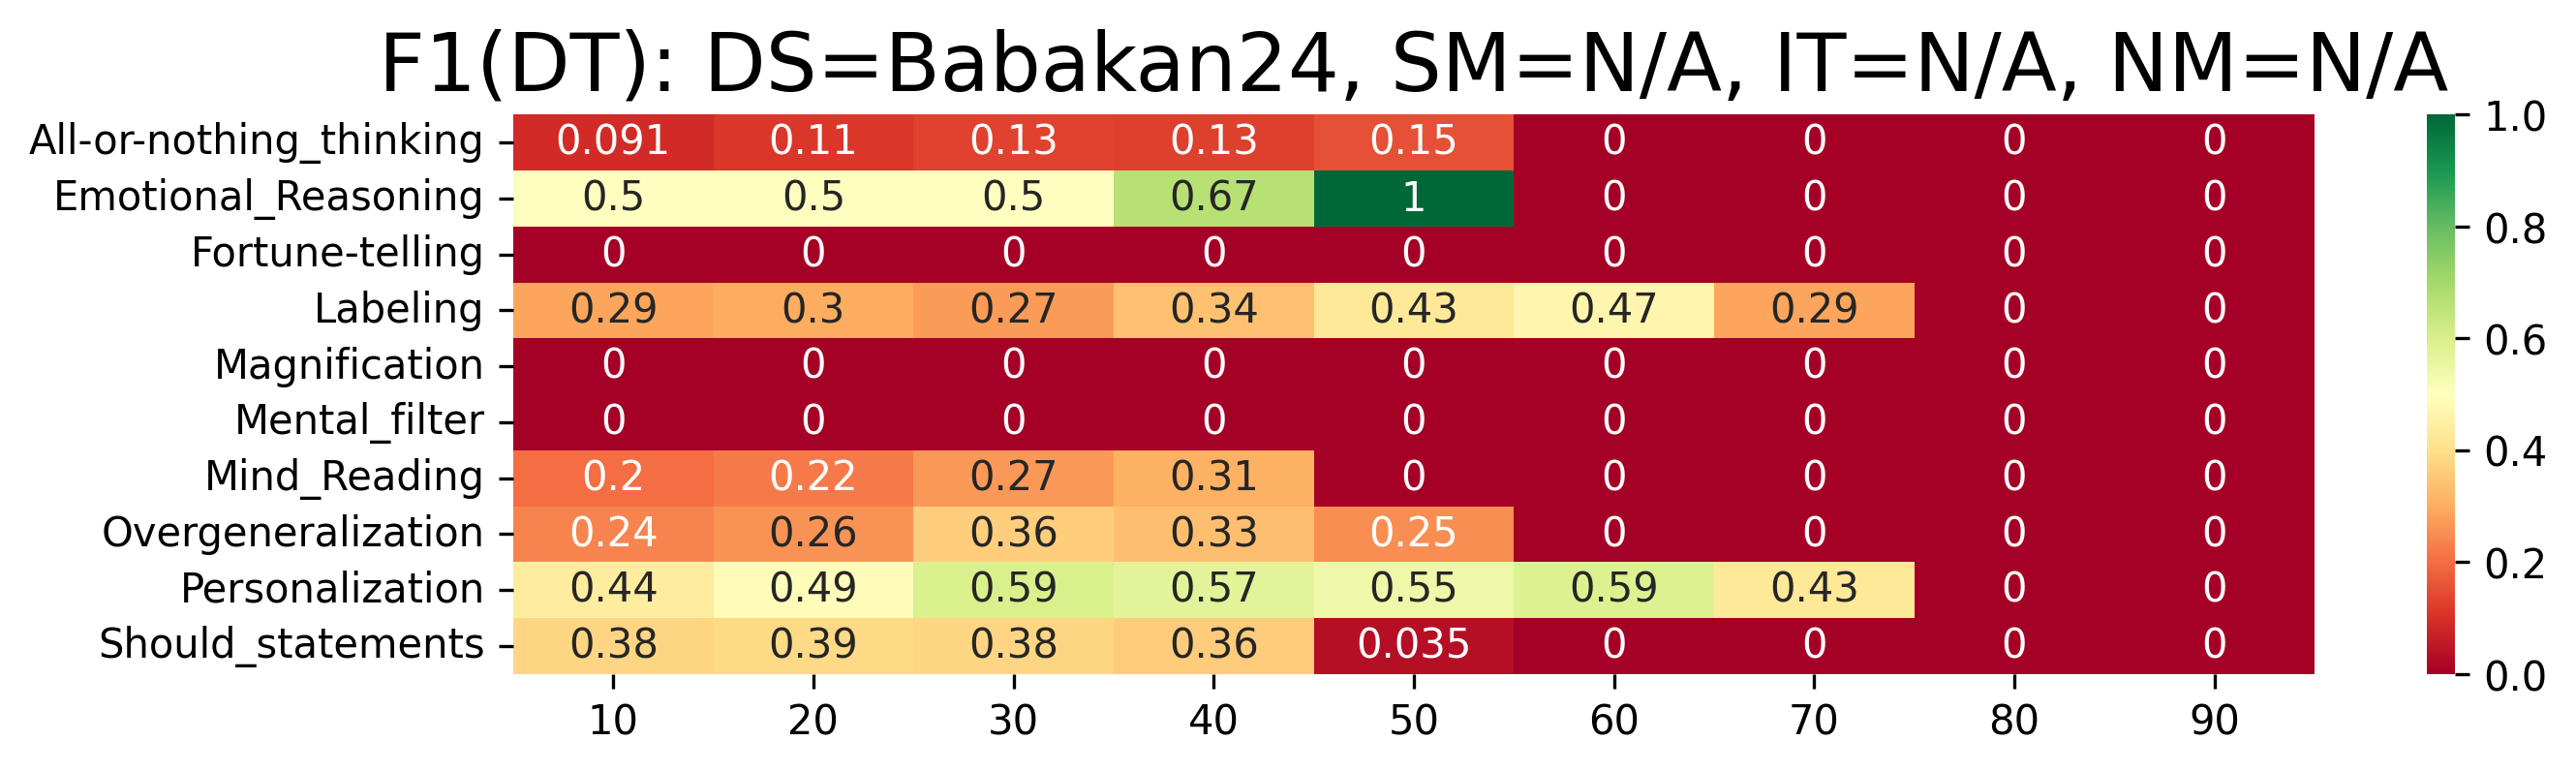

In [14]:
# Evaluate baseline model (Arinicheva and Kolonin 2025) within 3 splits

validation_fraction = 5
results_base = []
for shift in splits:
    test_df  = df[(df.index + shift) % validation_fraction == 0]
    accumulator_base = []
    evaluate_metrics(tm_base, test_df, 'N/A', detection_thresholds, DS, list(all_metricsmap), n_max='N/A', 
                selection_metric = 'N/A', f1_score=True, evaluator=our_evaluator_top1, accumulator=accumulator_base)
    results_base.append(accumulator_base)

In [15]:
# Print F1 performance of baseline model (Arinicheva and Kolonin 2025) within 3 splits

summary_base = []
for l1,l2,l3 in zip(results_base[0],results_base[1],results_base[2]):
    summary_base.append( l1[0:4] + agg_min_max_avg_mpe((l1[4],l2[4],l3[4])))
summary_base = sorted(summary_base, key=lambda x: (-x[6],x[3])) # sort by -F1avg, DT
summary_base[0]

('N/A',
 'N/A',
 'N/A',
 40,
 0.24994794295286904,
 0.31990777136623677,
 0.28018719919981244,
 9.45096047210874)

In [16]:
# Enter baseline F1 performance from the paper (Babacan, O˘guz, and Beyito˘glu 2025)
# https://dergipark.org.tr/tr/download/article-file/3865878, page 7

base_babakan = {'Mind_Reading': 0.8121,
'Overgeneralization': 0.6047,
'Magnification': 0.6483,
'Labelling': 0.8372,
'Personalization': 0.6946,
'Fortune-telling': 0.8193,
'Emotional_Reasoning': 0.6462,
'Mental_filter': 1.0000,
'Should_statements': 1.0000,
'All-or-nothing_thinking': 1.0000,
'Labeling': 0.4167}

numbers_babakan = [round(base_babakan[label],2) for label in labels]
print(numbers_babakan)

[1.0, 0.65, 0.82, 0.42, 0.65, 1.0, 0.81, 0.6, 0.69, 1.0]


2 60 FN 60
Shift=0: train=3623, test=907
Labels count: defaultdict(<class 'int'>, {'Mind_Reading': 349, 'Overgeneralization': 353, 'Magnification': 322, 'Labeling': 283, 'Personalization': 283, 'Fortune-telling': 268, 'Emotional_Reasoning': 272, 'Mental_filter': 257, 'Should_statements': 248, 'All-or-nothing_thinking': 236, 'No_Distortion': 752})


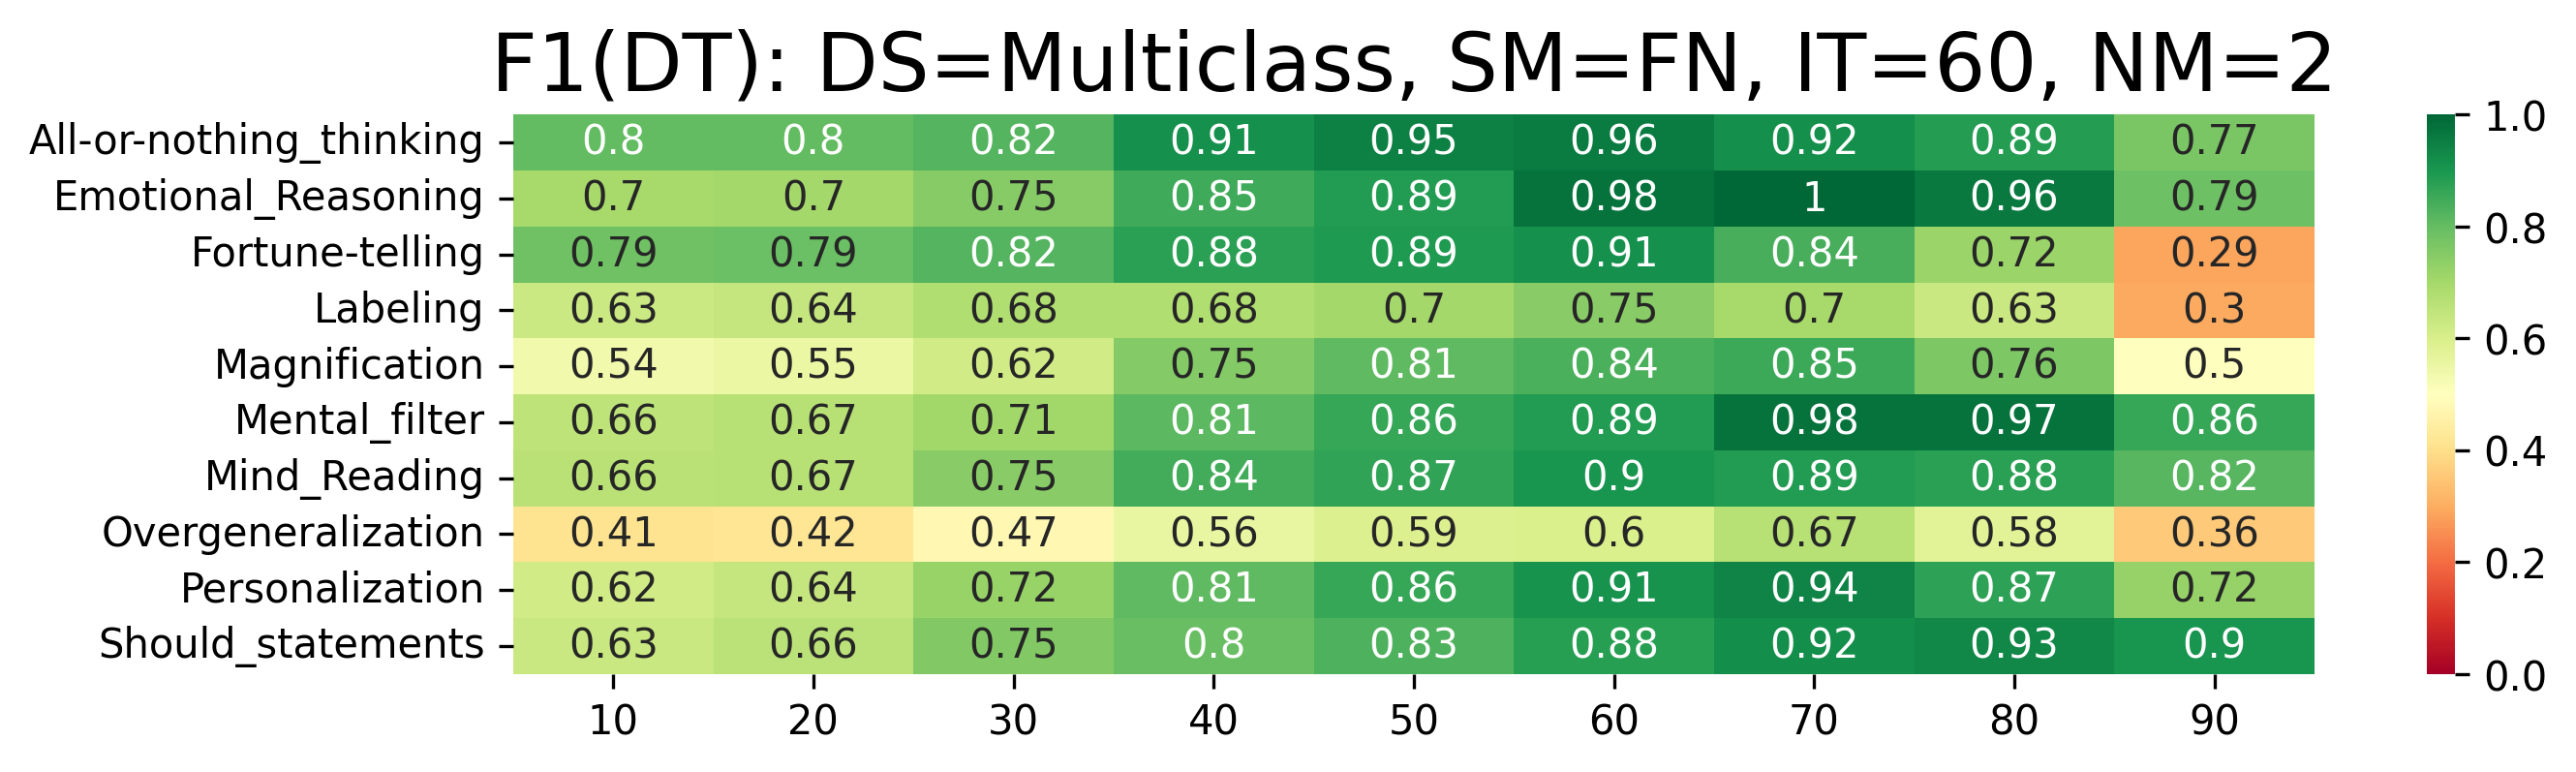

(2, 60, 'FN', 70, 0.8693080272493743, {'All-or-nothing_thinking': 0.9166666666666667, 'Emotional_Reasoning': 1.0, 'Fortune-telling': 0.8378378378378379, 'Labeling': 0.6956521739130435, 'Magnification': 0.8524590163934426, 'Mental_filter': 0.975609756097561, 'Mind_Reading': 0.888888888888889, 'Overgeneralization': 0.6666666666666666, 'Personalization': 0.9397590361445783, 'Should_statements': 0.9195402298850575})
['All-or-nothing_thinking', 'Emotional_Reasoning', 'Fortune-telling', 'Labeling', 'Magnification', 'Mental_filter', 'Mind_Reading', 'Overgeneralization', 'Personalization', 'Should_statements']
[0.92, 1.0, 0.84, 0.7, 0.85, 0.98, 0.89, 0.67, 0.94, 0.92]


In [17]:
# Re-compute distiortion-specific F1 performances

print(NM,IT,SM,DT) # 2 90 NLMI 10
shift = 0

accumulator = []
full_test_circle(df,model_multiclass_path,f'{model_name}-{shift+1}',
                validation_fraction=5,inclusion_thresholds=[IT],
                detection_thresholds=detection_thresholds,n_max=NM, selection_metrics = [SM],
                f1_score=True, split_shift=shift, evaluator=our_evaluator_top1, accumulator=accumulator)

best = sorted(accumulator, key=lambda x: (-x[4]))[0]
print(best)
labels = sorted(list(best[5]))
print(labels)
numbers_ours = [round(best[5][label],2) for label in labels]
print(numbers_ours)


In [18]:
# Visualize distiortion-specific F1 performances

metric_names = labels
model_metrics = {
'babakan25':   numbers_babakan,
'arinicheva25':   numbers_arinicheva,
'ours25': numbers_ours
}
fig = go.Figure()
for i in range(len(labels)):
    fig.add_trace(go.Bar(
        name=metric_names[i],
        x=list(model_metrics), y=[model_metrics[m][i] for m in model_metrics],
    ))
fig.update_layout(
    barmode='group', # Group bars by model
    title='F1 by model and label', # Add a title
    xaxis_title='Model', # Label the x-axis
    yaxis_title='F1', # Label the y-axis
    hovermode='closest' # Improve hover behavior
)
fig.show()

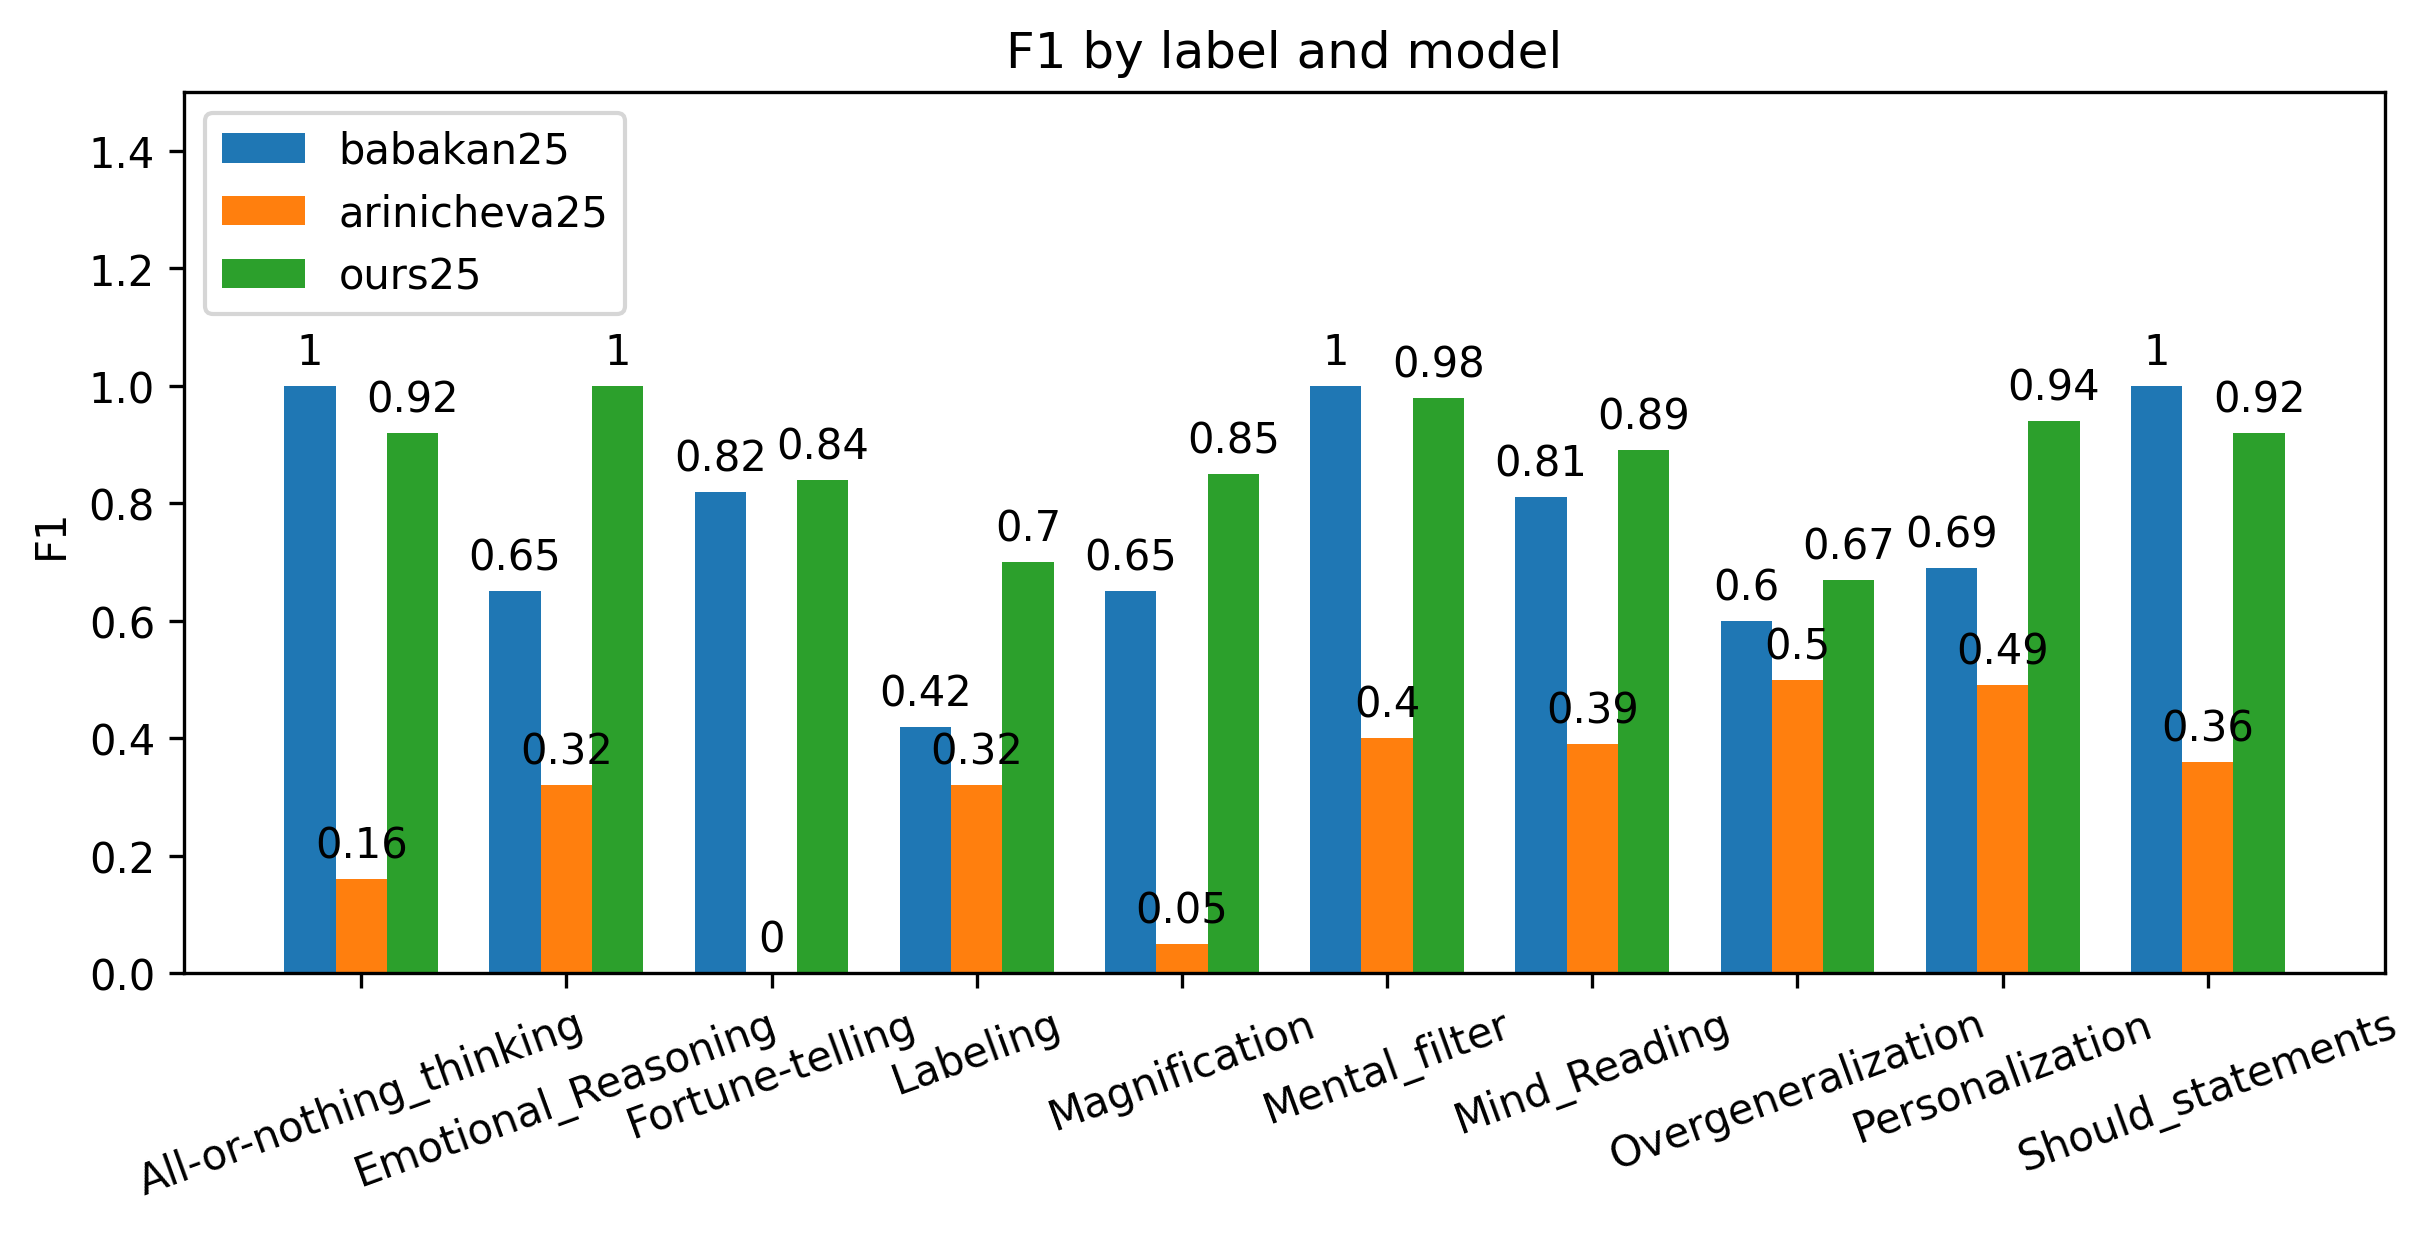

In [19]:
# Visualize distiortion-specific F1 performances

values = {
'babakan25':   numbers_babakan,
'arinicheva25':   numbers_arinicheva,
'ours25': numbers_ours
}

plt.rcParams["figure.figsize"] = (8,4)

x = np.arange(len(labels))  # the label locations
width = 0.25  # the width of the bars
multiplier = 0

fig, ax = plt.subplots(layout='constrained')

for attribute, measurement in values.items():
    offset = width * multiplier
    rects = ax.bar(x + offset, measurement, width, label=attribute)
    ax.bar_label(rects, padding=3)
    multiplier += 1

# Add some text for labels, title and custom x-axis tick labels, etc.
ax.set_ylabel('F1')
ax.set_title('F1 by label and model')
ax.set_xticks(x + width, labels)
ax.legend(loc='upper left')#, ncols=3)
ax.set_ylim(0, 1.5)
ax.tick_params(axis='x', rotation=20)
fig.set_dpi(300)

plt.show()

F1 babakan25: 0.7677
F1 arinicheva25: 0.28018719919981244%
F1 ours26: 0.9027830220931646%
F1 ours26-weighted: 0.8758896838128489%
MPE arinicheva25: 9.45096047210874%
MPE ours26: 1.1508516741452492%
MPE ours26-weighted: 1.4059324065187344%


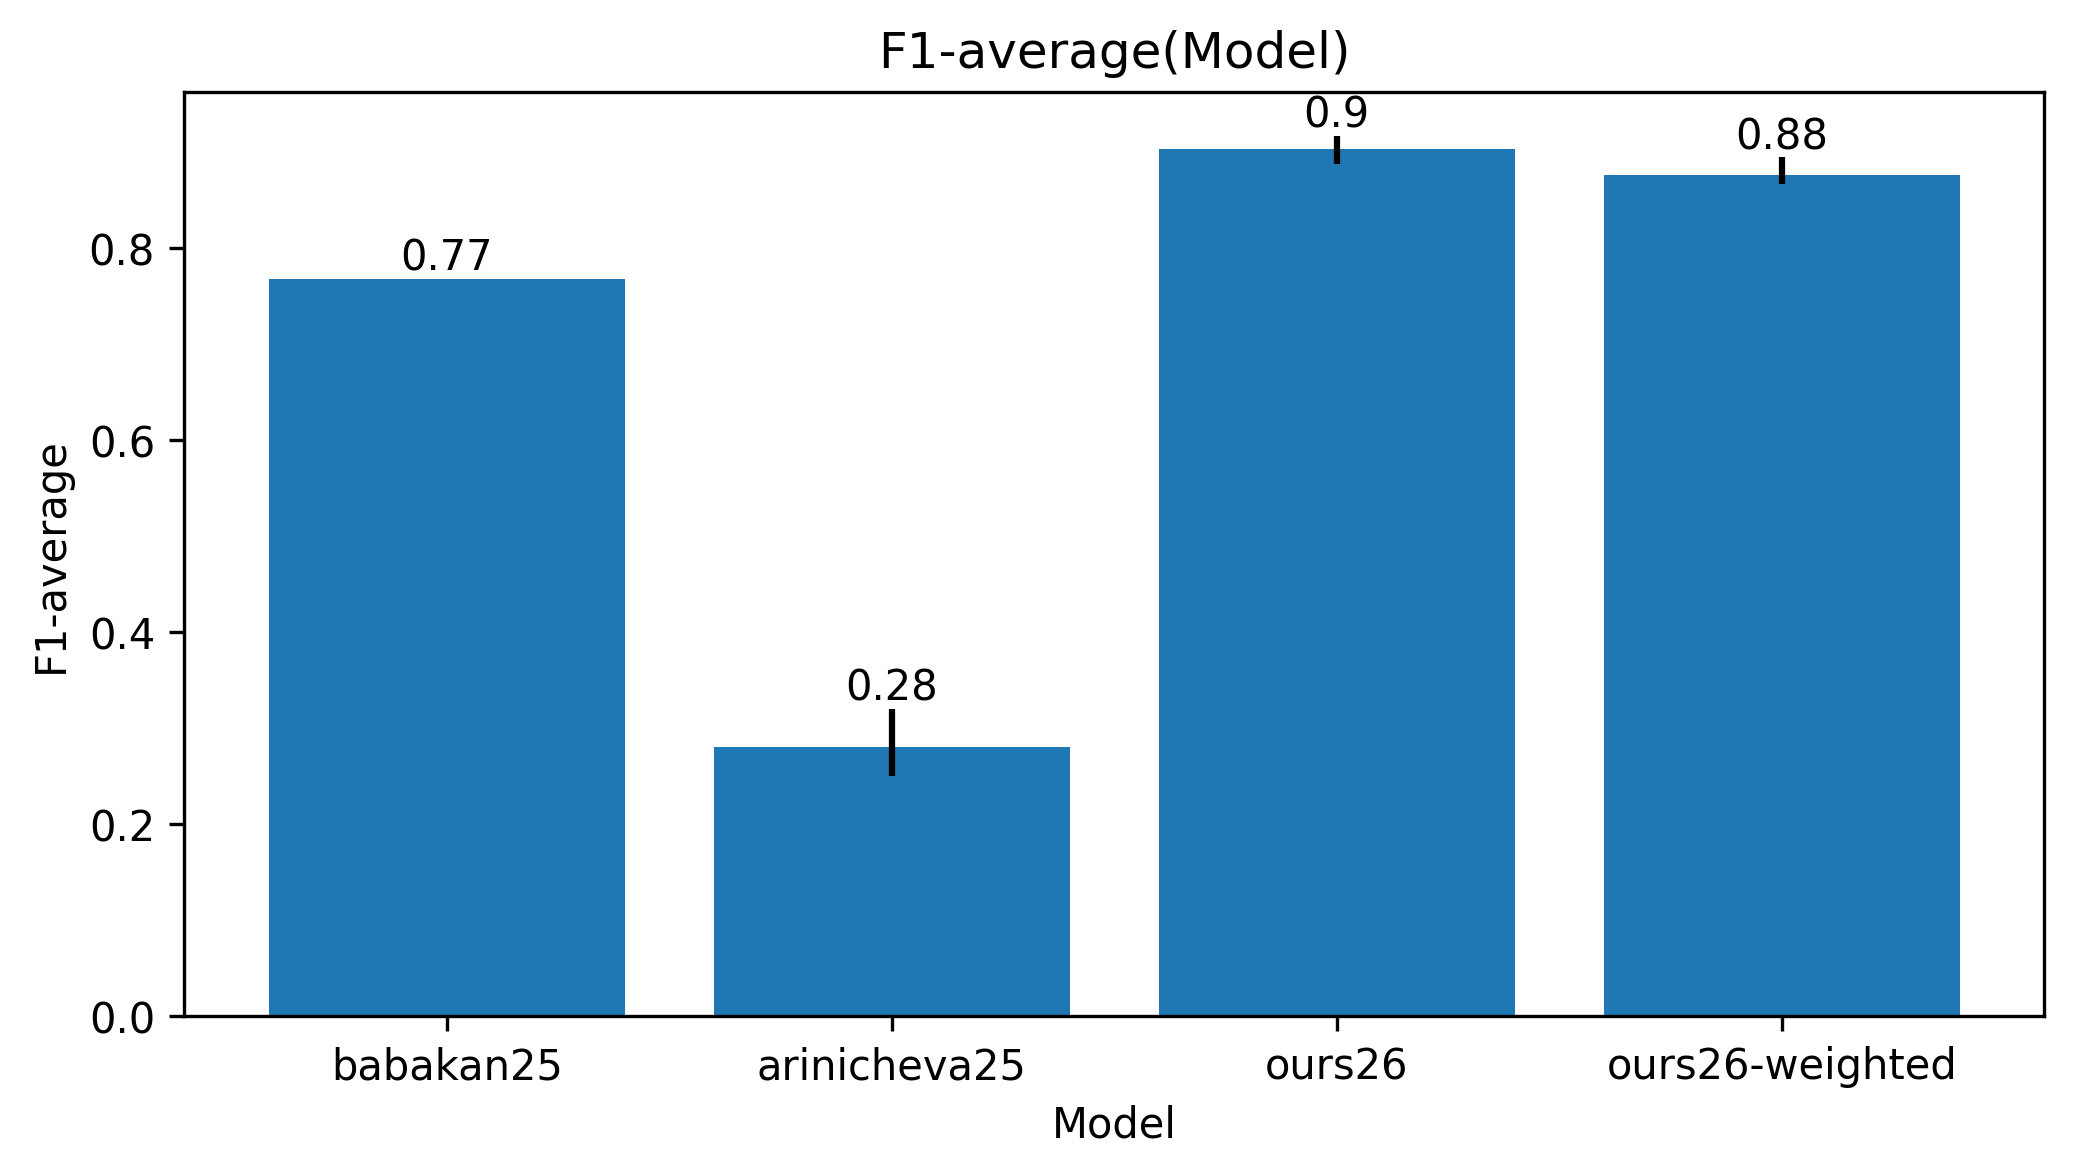

In [20]:
# Visualize grand baseline and our peformances, refering to papers 
# (Arinicheva and Kolonin 2025; Babacan, O˘guz, and Beyito˘glu 2025)  

# Paper Figure 3

# https://dergipark.org.tr/tr/download/article-file/3865878, page 7
print(f'F1 babakan25: 0.7677')
print(f'F1 arinicheva25: {summary_base[0][6]}%')
print(f'F1 ours26: {summary[0][6]}%')
print(f'F1 ours26-weighted: {summary_weighted[0][6]}%')
print(f'MPE arinicheva25: {summary_base[0][7]}%')
print(f'MPE ours26: {summary[0][7]}%')
print(f'MPE ours26-weighted: {summary_weighted[0][7]}%')
plot_bar_from_list_minmax('Model',['babakan25','arinicheva25','ours26','ours26-weighted'],
                          'F1-average',[0.7677,summary_base[0][6],summary[0][6],summary_weighted[0][6]],
                          minmax=[(0.7677,0.7677),(summary_base[0][4],summary_base[0][5]),
                                  (summary[0][4],summary[0][5]),(summary_weighted[0][4],summary_weighted[0][5])])


In [21]:
# Evaluate the computing time budget

grand_t1 = dt.datetime.now()
grand_delta = grand_t1 - grand_t0
str(grand_delta)

'6:57:00.292570'